In [ ]:
!pip install geemap earthengine-api xarray netCDF4 rasterio requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.9 MB/s eta 0:00:00


In [ ]:
"""
ISRO BAH 2026 - Problem Statement 3
PHASE 1, STEP 1: Pull all gridded satellite + fire + meteorology predictors
from Google Earth Engine as daily, multi-band GeoTIFFs over an India grid.

RUN THIS IN GOOGLE COLAB (easiest) or any machine with the Earth Engine
Python API authenticated.

What it produces:
    data/gee_grid/YYYY-MM-DD.tif   (one multi-band GeoTIFF per day)
    Bands, in order:
        0 NO2     - tropospheric NO2 column        (mol/m^2)
        1 SO2     - SO2 column                      (mol/m^2)
        2 CO      - CO column                       (mol/m^2)
        3 O3      - O3 column                       (mol/m^2)
        4 HCHO    - tropospheric HCHO column        (mol/m^2)   <-- Obj 2
        5 AOD     - MODIS MAIAC AOD @550nm          (unitless, x0.001 applied)
        6 FIRE    - active-fire brightness T21      (Kelvin; proxy for fire) <-- Obj 2
        7 T2M     - 2 m air temperature             (K)
        8 D2M     - 2 m dewpoint temperature        (K)  -> RH computed later
        9 U10     - 10 m wind, eastward             (m/s)
       10 V10     - 10 m wind, northward            (m/s)
       11 PRECIP  - total precipitation (daily sum) (m)

These 12 bands are your model INPUT channels. Surface AQI labels come from
the separate script 02_fetch_ground_openaq.py (CPCB via OpenAQ).
"""

# ----------------------------------------------------------------------
# 0. SETUP  (in Colab, run these once)
#    !pip install geemap earthengine-api -q
# ----------------------------------------------------------------------
import ee, geemap, os, datetime as dt

# Put YOUR Earth Engine cloud project id here (from console.cloud.google.com)
EE_PROJECT = "isro-project-499507"      # <<< EDIT THIS

ee.Authenticate()                       # opens a browser / pastes a token
ee.Initialize(project=EE_PROJECT)

# ----------------------------------------------------------------------
# 1. CONFIG  -- start SMALL, then widen once it works
# ----------------------------------------------------------------------
# India bounding box (lon_min, lat_min, lon_max, lat_max)
REGION = ee.Geometry.Rectangle([68.0, 8.0, 98.0, 37.0])

START = "2019-10-15"      # crop-burning season; widen to full Oct-Feb later
END   = "2019-11-15"      # END is exclusive
SCALE = 27830             # ~0.25 deg in metres. Use 11132 for ~0.1 deg (heavier)

OUT_DIR = "data/gee_grid"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# 2. DAILY COMPOSITE BUILDERS
#    Each returns a single-band ee.Image (daily mean over the region),
#    cloud-masked where a cloud band exists.
# ----------------------------------------------------------------------
def _s5p(collection, band, d0, d1, cloud_max=0.5):
    sel = [band] + (["cloud_fraction"] if cloud_max is not None else [])
    col = (ee.ImageCollection(collection)
             .filterDate(d0, d1)
             .filterBounds(REGION)
             .select(sel))
    def mask(img):
        if cloud_max is not None:
            img = img.updateMask(img.select("cloud_fraction").lt(cloud_max))
        return img.select(band)
    return col.map(mask).mean().rename(band)

def daily_image(date):
    d0 = ee.Date(date)
    d1 = d0.advance(1, "day")

    no2  = _s5p("COPERNICUS/S5P/OFFL/L3_NO2",  "tropospheric_NO2_column_number_density",  d0, d1).rename("NO2")
    so2  = _s5p("COPERNICUS/S5P/OFFL/L3_SO2",  "SO2_column_number_density",               d0, d1).rename("SO2")
    co   = _s5p("COPERNICUS/S5P/OFFL/L3_CO",   "CO_column_number_density",                d0, d1, cloud_max=None).rename("CO")
    o3   = _s5p("COPERNICUS/S5P/OFFL/L3_O3",   "O3_column_number_density",                d0, d1, cloud_max=None).rename("O3")
    hcho = _s5p("COPERNICUS/S5P/OFFL/L3_HCHO", "tropospheric_HCHO_column_number_density", d0, d1).rename("HCHO")

    # MODIS MAIAC AOD @ 550 nm (multiple granules/day -> mean). scale factor 0.001.
    aod = (ee.ImageCollection("MODIS/061/MCD19A2_GRANULES")
             .filterDate(d0, d1).filterBounds(REGION)
             .select("Optical_Depth_055").mean().multiply(0.001).rename("AOD"))

    # FIRMS active fire brightness (T21). unmask 0 so "no fire" = 0, not masked.
    fire = (ee.ImageCollection("FIRMS")
              .filterDate(d0, d1).filterBounds(REGION)
              .select("T21").max().unmask(0).rename("FIRE"))

    # ERA5-Land daily aggregate meteorology
    era = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").filterDate(d0, d1).filterBounds(REGION).first()
    t2m    = era.select("temperature_2m").rename("T2M")
    d2m    = era.select("dewpoint_temperature_2m").rename("D2M")
    u10    = era.select("u_component_of_wind_10m").rename("U10")
    v10    = era.select("v_component_of_wind_10m").rename("V10")
    precip = era.select("total_precipitation_sum").rename("PRECIP")

    img = (no2.addBands([so2, co, o3, hcho, aod, fire, t2m, d2m, u10, v10, precip])
              .toFloat().clip(REGION))
    return img

# ----------------------------------------------------------------------
# 3. LOOP OVER DAYS AND DOWNLOAD
# ----------------------------------------------------------------------
def daterange(start, end):
    d = dt.date.fromisoformat(start)
    last = dt.date.fromisoformat(end)
    while d < last:
        yield d.isoformat()
        d += dt.timedelta(days=1)

if __name__ == "__main__":
    for date in daterange(START, END):
        out = os.path.join(OUT_DIR, f"{date}.tif")
        if os.path.exists(out):
            print("skip (exists):", date); continue
        try:
            img = daily_image(date)
            # Direct download (fine for a 0.25-deg India grid: tiny file).
            geemap.ee_export_image(img, filename=out, scale=SCALE,
                                   region=REGION, file_per_band=False)
            print("ok  :", date)
        except Exception as e:
            print("FAIL:", date, "->", repr(e))

    print("\nDone. GeoTIFFs in:", OUT_DIR)
    print("Inspect one with:  import rasterio; rasterio.open('<file>').read().shape")

Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-15.tif
ok  : 2019-10-15
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-16.tif
ok  : 2019-10-16
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-17.tif
ok  : 2019-10-17
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-18.tif
ok  : 2019-10-18
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-19.tif
ok  : 2019-10-19
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-20.tif
ok  : 2019-10-20
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-21.tif
ok  : 2019-10-21
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-22.tif
ok  : 2019-10-22
Generating URL ...
Please wait ...
Data downloaded to /content/data/gee_grid/2019-10-23.tif
ok  : 2019-10-23
Generating URL ...


In [ ]:
import rasterio, glob
files = sorted(glob.glob("data/gee_grid/*.tif"))
print("number of files:", len(files))
ds = rasterio.open(files[0])
print("bands:", ds.count, "  size:", ds.shape)
print("band names:", ds.descriptions)

number of files: 31
bands: 12   size: (121, 121)
band names: (None, None, None, None, None, None, None, None, None, None, None, None)


In [ ]:
"""
ISRO BAH 2026 - Problem Statement 3
PHASE 1, STEP 2: Fetch ground-truth surface pollutant concentrations
(CPCB stations, mirrored by OpenAQ) -> these are your TRAINING LABELS.

OpenAQ v3 API. Free API key: https://openaq.org -> account -> API keys.

v2 of this script: adds proper RATE-LIMIT throttling (OpenAQ free tier is
~60 req/min) and a station cap so it finishes in minutes instead of hours.

Output: data/ground_labels.csv
    columns: station_id, station, lat, lon, date, pm25, pm10, no2, so2, co, o3
"""
import requests, time, csv, os
from collections import defaultdict

OPENAQ_KEY   = "e0213687ba92ca39691f1e57b7866287c24ec44eb37baf7578c52de6800df9f7 "
BBOX  = "68.0,8.0,98.0,37.0"             # India
START = "2024-10-15"
END   = "2024-11-15"
WANT  = {"pm25", "pm10", "no2", "so2", "co", "o3"}

MAX_LOCATIONS = 300      # cap stations (plenty for training; raise later if you like)
MIN_INTERVAL  = 1.1      # seconds between requests -> stays under 60/min

OUT = "data"; os.makedirs(OUT, exist_ok=True)
BASE = "https://api.openaq.org/v3"
HEAD = {"X-API-Key": OPENAQ_KEY}

_last = [0.0]
def _throttle():
    wait = MIN_INTERVAL - (time.time() - _last[0])
    if wait > 0:
        time.sleep(wait)
    _last[0] = time.time()

def get(url, params=None):
    """GET that respects the rate limit and waits out 429s instead of giving up."""
    for attempt in range(8):
        _throttle()
        r = requests.get(url, headers=HEAD, params=params, timeout=60)
        if r.status_code == 429:                       # rate limited
            retry = int(r.headers.get("Retry-After", 0)) or min(60, 5 * (attempt + 1))
            print(f"    rate-limited, waiting {retry}s...")
            time.sleep(retry)
            continue
        r.raise_for_status()
        return r.json()
    r.raise_for_status()

def list_india_locations():
    locs, page = [], 1
    while len(locs) < MAX_LOCATIONS:
        js = get(f"{BASE}/locations", {"bbox": BBOX, "limit": 100, "page": page})
        results = js.get("results", [])
        if not results:
            break
        locs.extend(results)
        if len(results) < 100:
            break
        page += 1
    return locs[:MAX_LOCATIONS]

def daily_for_sensor(sensor_id):
    out, page = [], 1
    while True:
        js = get(f"{BASE}/sensors/{sensor_id}/measurements/daily",
                 {"datetime_from": START, "datetime_to": END, "limit": 1000, "page": page})
        results = js.get("results", [])
        if not results:
            break
        out.extend(results)
        if len(results) < 1000:
            break
        page += 1
    return out

if __name__ == "__main__":
    locations = list_india_locations()
    print(f"Using {len(locations)} OpenAQ locations (cap={MAX_LOCATIONS}).")

    table = defaultdict(dict); meta = {}
    for i, loc in enumerate(locations, 1):
        sid = loc["id"]
        coords = loc.get("coordinates") or {}
        meta[sid] = (loc.get("name", ""), coords.get("latitude"), coords.get("longitude"))
        for sensor in loc.get("sensors", []):
            param = (sensor.get("parameter") or {}).get("name", "").lower()
            if param not in WANT:
                continue
            try:
                for m in daily_for_sensor(sensor["id"]):
                    day = (m.get("period", {}).get("datetimeFrom", {}).get("local", "") or "")[:10]
                    val = m.get("value")
                    if day and val is not None:
                        table[(sid, day)][param] = val
            except Exception as e:
                print("  sensor fail", sensor.get("id"), repr(e)[:60])
        if i % 20 == 0:
            print(f"  ...{i}/{len(locations)} locations  ({len(table)} rows so far)")

    path = os.path.join(OUT, "ground_labels.csv")
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["station_id","station","lat","lon","date","pm25","pm10","no2","so2","co","o3"])
        for (sid, day), vals in sorted(table.items()):
            name, lat, lon = meta[sid]
            w.writerow([sid, name, lat, lon, day] +
                       [vals.get(p, "") for p in ("pm25","pm10","no2","so2","co","o3")])
    print(f"\nWrote {path}  ({len(table)} station-day rows)")

Using 300 OpenAQ locations (cap=300).
  ...20/300 locations  (0 rows so far)
  ...40/300 locations  (0 rows so far)


KeyboardInterrupt: 

In [ ]:
import requests, json
KEY = "e0213687ba92ca39691f1e57b7866287c24ec44eb37baf7578c52de6800df9f7 "          # same key
H = {"X-API-Key": KEY}

# grab a few locations and show their sensors
loc = requests.get("https://api.openaq.org/v3/locations",
        headers=H, params={"bbox":"68,8,98,37","limit":5,"page":1}).json()
sensors = []
for L in loc["results"]:
    for s in L.get("sensors", []):
        sensors.append((s["id"], s["parameter"]["name"]))
print("sample sensors:", sensors[:10])

# try fetching daily data for the first sensor
sid = sensors[0][0]
r = requests.get(f"https://api.openaq.org/v3/sensors/{sid}/measurements/daily",
        headers=H, params={"datetime_from":"2024-10-15","datetime_to":"2024-11-15","limit":5}).json()
print("\nraw daily response for sensor", sid, ":")
print(json.dumps(r, indent=2)[:2000])

sample sensors: [(23, 'pm25'), (13866, 'no2'), (24, 'o3'), (13864, 'pm25'), (27, 'co'), (28, 'no2'), (29, 'o3'), (26, 'pm10'), (30, 'pm25'), (33, 'co')]

raw daily response for sensor 23 :
{
  "meta": {
    "name": "openaq-api",
    "website": "/",
    "page": 1,
    "limit": 5,
    "found": 0
  },
  "results": []
}


In [ ]:
import requests, json
KEY = "e0213687ba92ca39691f1e57b7866287c24ec44eb37baf7578c52de6800df9f7 "
H = {"X-API-Key": KEY}
sid = 23

# 1) what date range does this sensor actually cover?
info = requests.get(f"https://api.openaq.org/v3/sensors/{sid}", headers=H).json()
print(json.dumps(info["results"][0].get("datetimeFirst"), indent=2))
print(json.dumps(info["results"][0].get("datetimeLast"), indent=2))

# 2) daily data with NO date filter — does anything come back at all?
r = requests.get(f"https://api.openaq.org/v3/sensors/{sid}/measurements/daily",
        headers=H, params={"limit":3}).json()
print("found (no date filter):", r["meta"]["found"])
for x in r["results"][:3]:
    print(x.get("period",{}).get("datetimeFrom",{}).get("utc"), "->", x.get("value"))

null
null
found (no date filter): 0


In [ ]:
!pip install kaggle -q
from google.colab import files; files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rohanrao/air-quality-data-in-india -p data/cpcb --unzip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
License(s): CC0-1.0
100% 72.9M/72.9M [00:00<00:00, 105MB/s]



In [ ]:
"""
ISRO BAH 2026 - PS3, Phase 1, STEP 2 (v3)
Ground-truth labels from the CPCB historical dataset on Kaggle.
(We switched away from OpenAQ because it no longer carries Indian CPCB data.)

Dataset: rohanrao/air-quality-data-in-india  -> city_day.csv (CPCB, 2015-2020)
Window:  align with your satellite data (default Oct-Nov 2019).

SETUP IN COLAB (one time):
    1. kaggle.com -> your profile -> Settings -> "Create New API Token"
       (downloads kaggle.json)
    2. Run, then upload kaggle.json when prompted:

        !pip install kaggle -q
        from google.colab import files; files.upload()      # pick kaggle.json
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
        !kaggle datasets download -d rohanrao/air-quality-data-in-india -p data/cpcb --unzip

    3. Then run THIS script.

Output: data/ground_labels.csv
    columns: station_id, station, lat, lon, date, pm25, pm10, no2, so2, co, o3
"""
import pandas as pd, os, unicodedata

CITY_DAY = "data/cpcb/city_day.csv"
START = "2019-10-15"
END   = "2019-11-15"          # inclusive; match your GEE window
OUT   = "data"; os.makedirs(OUT, exist_ok=True)

# CPCB monitoring cities in this dataset -> (lat, lon).
CITY_LATLON = {
    "Ahmedabad": (23.03, 72.58), "Aizawl": (23.73, 92.72), "Amaravati": (16.57, 80.36),
    "Amritsar": (31.63, 74.87), "Bengaluru": (12.97, 77.59), "Bhopal": (23.26, 77.41),
    "Brajrajnagar": (21.82, 83.92), "Chandigarh": (30.73, 76.78), "Chennai": (13.08, 80.27),
    "Coimbatore": (11.02, 76.96), "Delhi": (28.61, 77.21), "Ernakulam": (9.98, 76.28),
    "Gurugram": (28.46, 77.03), "Guwahati": (26.14, 91.74), "Hyderabad": (17.38, 78.49),
    "Jaipur": (26.91, 75.79), "Jorapokhar": (23.71, 86.41), "Kochi": (9.93, 76.27),
    "Kolkata": (22.57, 88.36), "Lucknow": (26.85, 80.95), "Mumbai": (19.08, 72.88),
    "Patna": (25.59, 85.14), "Shillong": (25.58, 91.89), "Talcher": (20.95, 85.23),
    "Thiruvananthapuram": (8.52, 76.94), "Visakhapatnam": (17.69, 83.22),
}

df = pd.read_csv(CITY_DAY)
print("raw columns:", list(df.columns))

# keep our window
df["Date"] = pd.to_datetime(df["Date"])
df = df[(df["Date"] >= START) & (df["Date"] <= END)].copy()

# map dataset columns -> our schema (CPCB CO is already mg/m3)
ren = {"PM2.5": "pm25", "PM10": "pm10", "NO2": "no2",
       "SO2": "so2", "CO": "co", "O3": "o3"}
df = df.rename(columns=ren)

rows = []
for _, r in df.iterrows():
    city = r["City"]
    if city not in CITY_LATLON:
        continue
    lat, lon = CITY_LATLON[city]
    rows.append({
        "station_id": city.lower().replace(" ", "_"),
        "station": city, "lat": lat, "lon": lon,
        "date": r["Date"].date().isoformat(),
        "pm25": r.get("pm25"), "pm10": r.get("pm10"), "no2": r.get("no2"),
        "so2": r.get("so2"), "co": r.get("co"), "o3": r.get("o3"),
    })

out = pd.DataFrame(rows, columns=["station_id","station","lat","lon","date",
                                  "pm25","pm10","no2","so2","co","o3"])
path = os.path.join(OUT, "ground_labels.csv")
out.to_csv(path, index=False)
print(f"\nWrote {path}")
print(f"  {len(out)} city-day label rows, {out['station'].nunique()} cities")
print(out.head(8).to_string(index=False))

raw columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Wrote data/ground_labels.csv
  736 city-day label rows, 23 cities
station_id   station   lat   lon       date   pm25   pm10    no2    so2    co     o3
 ahmedabad Ahmedabad 23.03 72.58 2019-10-15  96.74 208.83 229.45 156.50 57.78  59.05
 ahmedabad Ahmedabad 23.03 72.58 2019-10-16  90.70 188.75 219.01 135.76 51.18  77.07
 ahmedabad Ahmedabad 23.03 72.58 2019-10-17 100.06 175.79 239.10 134.84 39.85  59.32
 ahmedabad Ahmedabad 23.03 72.58 2019-10-18 109.01 174.56 217.53    NaN 40.53  73.44
 ahmedabad Ahmedabad 23.03 72.58 2019-10-19  87.87 154.68 186.56 100.46  6.94  93.28
 ahmedabad Ahmedabad 23.03 72.58 2019-10-20  89.05 129.36 159.10 105.73  5.69  76.58
 ahmedabad Ahmedabad 23.03 72.58 2019-10-21  81.62 118.57 121.02 117.20  1.70 114.49
 ahmedabad Ahmedabad 23.03 72.58 2019-10-22  84.90 128.62 108.85 113.16  3.67 133.14


In [ ]:
"""
ISRO BAH 2026 - PS3, PHASE 2, STEP 1: Build the training table.

For every CPCB label (city, date) we extract from the satellite GeoTIFFs:
  - a KxK spatial PATCH of all 12 bands, centred on the city
  - over the previous T days (so the LSTM sees a time sequence)
That patch-sequence is the INPUT (X); the city's surface pollutants are the TARGET (y).

Output: data/train.npz  with
    X     float32 (N, T, K, K, 12)   model inputs
    Y     float32 (N, 5)             targets [pm25, no2, so2, co, o3]
    meta  (N, 2) strings             [city, date] for traceability
    target_names, band_names

Needs: rasterio, numpy, pandas  (already installed in your Colab).
"""
import numpy as np, pandas as pd, rasterio, os, datetime as dt

GRID_DIR = "data/gee_grid"
LABELS   = "data/ground_labels.csv"
OUT      = "data/train.npz"

T = 5            # days of history per sample (the LSTM time dimension)
K = 5            # patch size KxK (spatial context for the CNN); must be odd
TARGETS = ["pm25", "no2", "so2", "co", "o3"]   # surface values we predict
BANDS = ["NO2","SO2","CO","O3","HCHO","AOD","FIRE","T2M","D2M","U10","V10","PRECIP"]

# ---- helpers ---------------------------------------------------------------
def tif_path(date):
    return os.path.join(GRID_DIR, f"{date}.tif")

def load_day(date, pad):
    """Return an edge-padded (12, H+2pad, W+2pad) array for one day, or None."""
    p = tif_path(date)
    if not os.path.exists(p):
        return None
    with rasterio.open(p) as ds:
        arr = ds.read().astype("float32")               # (12, H, W)
        arr[arr == ds.nodata] = np.nan if ds.nodata is not None else arr
    return np.pad(arr, ((0,0),(pad,pad),(pad,pad)), mode="edge")

def rowcol(lat, lon):
    """Pixel row/col of a lat/lon in the grid (same for every daily tif)."""
    with rasterio.open(tif_path_any()) as ds:
        r, c = ds.index(lon, lat)
    return r, c

def tif_path_any():
    for f in sorted(os.listdir(GRID_DIR)):
        if f.endswith(".tif"):
            return os.path.join(GRID_DIR, f)
    raise FileNotFoundError("No GeoTIFFs in " + GRID_DIR)

# ---- build -----------------------------------------------------------------
df = pd.read_csv(LABELS)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df.dropna(subset=["pm25"])          # need at least PM2.5 as anchor target
pad = K // 2

# cache padded daily arrays so we only read each tif once
cache = {}
def get_day(date):
    if date not in cache:
        cache[date] = load_day(date, pad)
    return cache[date]

X, Y, meta = [], [], []
skipped = 0
for _, row in df.iterrows():
    d0 = row["date"]
    days = [(d0 - dt.timedelta(days=k)).isoformat() for k in range(T-1, -1, -1)]  # oldest->newest
    arrs = [get_day(dd) for dd in days]
    if any(a is None for a in arrs):     # missing a day in the window
        skipped += 1; continue
    r, c = rowcol(row["lat"], row["lon"])
    rp, cp = r + pad, c + pad            # shift for padding
    seq = []
    for a in arrs:
        patch = a[:, rp-pad:rp+pad+1, cp-pad:cp+pad+1]   # (12, K, K)
        seq.append(np.transpose(patch, (1, 2, 0)))       # (K, K, 12)
    X.append(np.stack(seq, axis=0))                      # (T, K, K, 12)
    Y.append([row.get(t, np.nan) for t in TARGETS])
    meta.append([row["station"], d0.isoformat()])

X = np.asarray(X, dtype="float32")
Y = np.asarray(Y, dtype="float32")
meta = np.asarray(meta)

# fill remaining predictor gaps (clouds) with per-band median
for b in range(X.shape[-1]):
    med = np.nanmedian(X[..., b])
    X[..., b] = np.nan_to_num(X[..., b], nan=med)

# fill missing non-PM targets with column median (PM2.5 already non-null)
for j in range(Y.shape[1]):
    col = Y[:, j]
    med = np.nanmedian(col)
    Y[:, j] = np.where(np.isnan(col), med, col)

np.savez_compressed(OUT, X=X, Y=Y, meta=meta,
                    target_names=np.array(TARGETS), band_names=np.array(BANDS))
print(f"Saved {OUT}")
print(f"  X shape {X.shape}  (samples, days, patch, patch, bands)")
print(f"  Y shape {Y.shape}  targets={TARGETS}")
print(f"  samples kept: {len(X)}   skipped (incomplete window): {skipped}")
print(f"  cities: {len(set(meta[:,0]))}   date span: {meta[:,1].min()} -> {meta[:,1].max()}")

Saved data/train.npz
  X shape (597, 5, 5, 5, 12)  (samples, days, patch, patch, bands)
  Y shape (597, 5)  targets=['pm25', 'no2', 'so2', 'co', 'o3']
  samples kept: 597   skipped (incomplete window): 114


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U18'), dtype('<U18')) -> None

In [ ]:
"""
ISRO BAH 2026 - PS3, PHASE 2, STEP 2: Train the CNN-LSTM (Objective 1).

Reads data/train.npz, trains a CNN-LSTM that maps a patch-sequence of
satellite+met bands -> surface pollutant concentrations, and validates on
HELD-OUT CITIES (the real test: can it predict where there is NO monitor?).

Saves:
    models/cnn_lstm.keras     trained model
    models/scalers.npz        normalisation stats (needed for Phase 3 maps)

Needs: tensorflow (preinstalled in Colab), numpy, scikit-learn.
"""
import numpy as np, os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, r2_score

DATA = "data/train.npz"
os.makedirs("models", exist_ok=True)
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

d = np.load(DATA, allow_pickle=True)
X, Y, meta = d["X"], d["Y"], d["meta"]
TARGETS = list(d["target_names"])
N, T, K, _, C = X.shape
print("X", X.shape, "Y", Y.shape, "targets", TARGETS)

# ---- split by CITY (spatial hold-out) --------------------------------------
cities = np.array(sorted(set(meta[:, 0])))
rng = np.random.default_rng(SEED); rng.shuffle(cities)
n_val = max(3, int(0.25 * len(cities)))
val_cities = set(cities[:n_val])
is_val = np.array([c in val_cities for c in meta[:, 0]])
print(f"{len(cities)} cities -> {n_val} held out for validation: {sorted(val_cities)}")

Xtr, Ytr = X[~is_val], Y[~is_val]
Xva, Yva = X[is_val],  Y[is_val]

# ---- normalise -------------------------------------------------------------
xmean = Xtr.reshape(-1, C).mean(0); xstd = Xtr.reshape(-1, C).std(0) + 1e-6
def nx(a): return (a - xmean) / xstd
ymean = Ytr.mean(0); ystd = Ytr.std(0) + 1e-6
def ny(a): return (a - ymean) / ystd
def iy(a): return a * ystd + ymean        # invert -> real concentrations

Xtr_n, Xva_n = nx(Xtr), nx(Xva)
Ytr_n, Yva_n = ny(Ytr), ny(Yva)

# ---- model -----------------------------------------------------------------
inp = layers.Input((T, K, K, C))
x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(inp)
x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(x)
x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)   # (T, 32)
x = layers.LSTM(64)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(len(TARGETS))(x)
model = models.Model(inp, out)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

es = callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")
hist = model.fit(Xtr_n, Ytr_n, validation_data=(Xva_n, Yva_n),
                 epochs=200, batch_size=32, callbacks=[es], verbose=2)

# ---- evaluate on held-out cities (real concentration units) ----------------
pred = iy(model.predict(Xva_n, verbose=0))
pred = np.clip(pred, 0, None)
print("\n=== Validation on held-out cities (real units) ===")
for j, t in enumerate(TARGETS):
    mae = mean_absolute_error(Yva[:, j], pred[:, j])
    r2  = r2_score(Yva[:, j], pred[:, j])
    print(f"  {t:5s}  MAE={mae:8.2f}   R2={r2:6.3f}")
print("  (PM2.5 is the most reliable metric; other targets had some imputed values.)")

model.save("models/cnn_lstm.keras")
np.savez("models/scalers.npz", xmean=xmean, xstd=xstd, ymean=ymean, ystd=ystd,
         target_names=np.array(TARGETS))
print("\nSaved models/cnn_lstm.keras and models/scalers.npz")

X (597, 5, 5, 5, 12) Y (597, 5) targets [np.str_('pm25'), np.str_('no2'), np.str_('so2'), np.str_('co'), np.str_('o3')]
23 cities -> 5 held out for validation: [np.str_('Gurugram'), np.str_('Lucknow'), np.str_('Mumbai'), np.str_('Patna'), np.str_('Visakhapatnam')]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 5, 5, 12)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 5, 5, 32)    │         3,488 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 5, 5, 32)    │         9,248 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,053 (164.27 KB)

 Trainable params: 42,053 (164.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
15/15 - 6s - 384ms/step - loss: 0.9509 - mae: 0.5444 - val_loss: 0.8311 - val_mae: 0.5878
Epoch 2/200
15/15 - 0s - 33ms/step - loss: 0.8182 - mae: 0.4697 - val_loss: 0.6410 - val_mae: 0.5448
Epoch 3/200
15/15 - 0s - 31ms/step - loss: 0.6606 - mae: 0.4401 - val_loss: 0.6758 - val_mae: 0.5841
Epoch 4/200
15/15 - 0s - 32ms/step - loss: 0.5309 - mae: 0.4183 - val_loss: 0.7201 - val_mae: 0.6172
Epoch 5/200
15/15 - 0s - 31ms/step - loss: 0.4438 - mae: 0.3831 - val_loss: 0.7159 - val_mae: 0.6106
Epoch 6/200
15/15 - 0s - 30ms/step - loss: 0.3767 - mae: 0.3574 - val_loss: 0.7714 - val_mae: 0.6330
Epoch 7/200
15/15 - 0s - 31ms/step - loss: 0.3459 - mae: 0.3422 - val_loss: 0.6789 - val_mae: 0.5814
Epoch 8/200
15/15 - 0s - 30ms/step - loss: 0.3105 - mae: 0.3246 - val_loss: 0.7151 - val_mae: 0.5782
Epoch 9/200
15/15 - 0s - 32ms/step - loss: 0.2851 - mae: 0.3122 - val_loss: 0.6444 - val_mae: 0.5484
Epoch 10/200
15/15 - 0s - 30ms/step - loss: 0.2767 - mae: 0.3062 - val_loss: 0.6580 - val_

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step
Saved output/aqi_map_2019-11-08.png
AQI range: 24 - 375  mean: 136


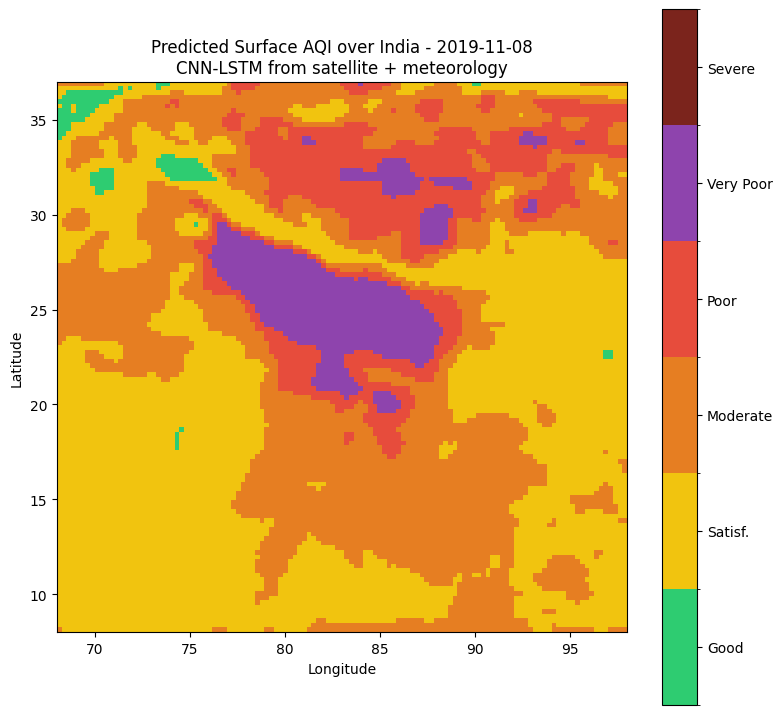

In [ ]:
"""
ISRO BAH 2026 - PS3, PHASE 3, STEP 1: National surface-AQI heatmap (Objective 1).

Runs the trained CNN-LSTM over EVERY grid cell in India for one date, converts
the predicted pollutants to CPCB AQI, and renders a heatmap over the country.

Output: output/aqi_map_<DATE>.png   and   output/aqi_grid_<DATE>.npy

Needs: tensorflow, numpy, rasterio, matplotlib.
"""
import numpy as np, rasterio, os, datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from numpy.lib.stride_tricks import sliding_window_view

GRID_DIR = "data/gee_grid"
DATE = "2019-11-08"      # a peak-burning day; change to any date you downloaded
T, K = 5, 5
EXTENT = [68.0, 98.0, 8.0, 37.0]     # lon_min, lon_max, lat_min, lat_max
os.makedirs("output", exist_ok=True)

# ---- CPCB AQI from the 5 predicted pollutants (vectorised) -----------------
IP = [0, 50, 100, 200, 300, 400, 500]
CP = {  # concentration breakpoints (CO in mg/m3, rest ug/m3)
 "pm25":[0,30,60,90,120,250,500], "no2":[0,40,80,180,280,400,1000],
 "so2":[0,40,80,380,800,1600,2620], "co":[0,1,2,10,17,34,50],
 "o3":[0,50,100,168,208,748,1000]}
def aqi_from(pred, names):
    subs = [np.interp(pred[..., j], CP[t], IP) for j, t in enumerate(names)]
    return np.max(np.stack(subs, -1), -1)     # worst-pollutant rule

# ---- load model + scalers --------------------------------------------------
model = tf.keras.models.load_model("models/cnn_lstm.keras")
s = np.load("models/scalers.npz", allow_pickle=True)
xmean, xstd, ymean, ystd = s["xmean"], s["xstd"], s["ymean"], s["ystd"]
TARGETS = list(s["target_names"])

# ---- build the patch-sequence for every pixel ------------------------------
def day_array(date):
    p = os.path.join(GRID_DIR, f"{date}.tif")
    with rasterio.open(p) as ds:
        a = ds.read().astype("float32")           # (C, H, W)
        if ds.nodata is not None: a[a == ds.nodata] = np.nan
    return a

d0 = dt.date.fromisoformat(DATE)
days = [(d0 - dt.timedelta(days=k)).isoformat() for k in range(T-1, -1, -1)]
stack = [day_array(dd) for dd in days]            # list of (C,H,W)
C, H, W = stack[0].shape
pad = K // 2

seq = np.empty((H*W, T, K, K, C), dtype="float32")
for ti, a in enumerate(stack):
    a = np.transpose(a, (1, 2, 0))                # (H, W, C)
    a = np.pad(a, ((pad,pad),(pad,pad),(0,0)), mode="edge")
    win = sliding_window_view(a, (K, K), axis=(0, 1))  # (H, W, C, K, K)
    win = np.transpose(win, (0, 1, 3, 4, 2)).reshape(H*W, K, K, C)
    seq[:, ti] = win

# normalise (NaN -> mean -> 0 after z-score)
seq = (seq - xmean) / xstd
seq = np.nan_to_num(seq, nan=0.0)

# ---- predict over the whole grid -------------------------------------------
pred = model.predict(seq, batch_size=2048, verbose=1)
pred = pred * ystd + ymean
pred = np.clip(pred, 0, None)
aqi = aqi_from(pred, TARGETS).reshape(H, W)
np.save(f"output/aqi_grid_{DATE}.npy", aqi)

# ---- plot ------------------------------------------------------------------
bounds = [0, 50, 100, 200, 300, 400, 500]
colors = ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C", "#8E44AD", "#7B241C"]
cmap = ListedColormap(colors); norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8, 9))
im = plt.imshow(aqi, extent=EXTENT, origin="upper", cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[25,75,150,250,350,450], shrink=0.8)
cbar.ax.set_yticklabels(["Good","Satisf.","Moderate","Poor","Very Poor","Severe"])
plt.title(f"Predicted Surface AQI over India - {DATE}\nCNN-LSTM from satellite + meteorology")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"output/aqi_map_{DATE}.png", dpi=150)
print("Saved output/aqi_map_%s.png" % DATE)
print("AQI range:", int(np.nanmin(aqi)), "-", int(np.nanmax(aqi)),
      " mean:", int(np.nanmean(aqi)))

HCHO threshold (mean+2sd) = 3.034e-04 mol/m^2; hotspot cells = 411


Saved output/hcho_hotspots_2019-11-08.png


Saved output/hcho_fire_corr.png  (HCHO-fire correlation r = -0.01)


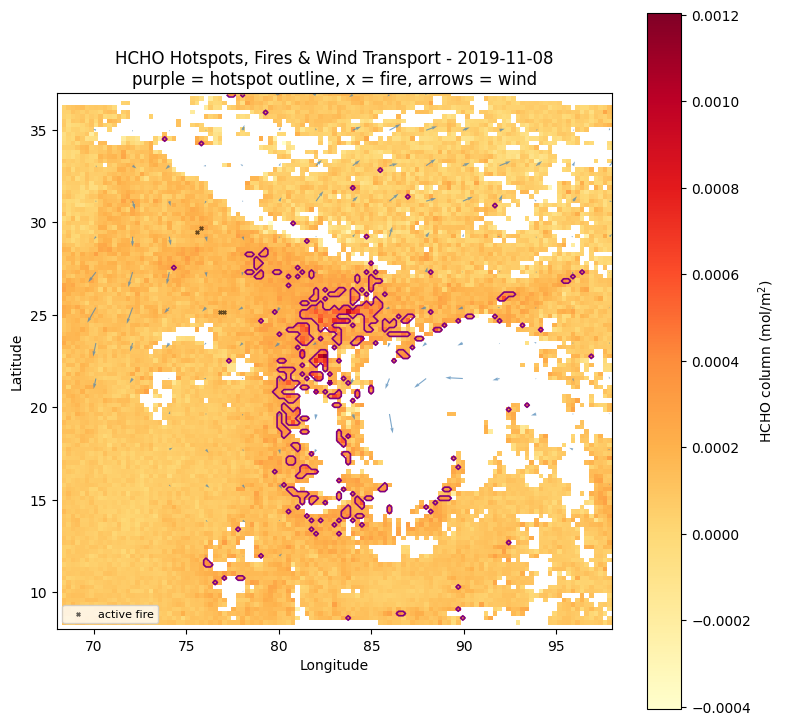

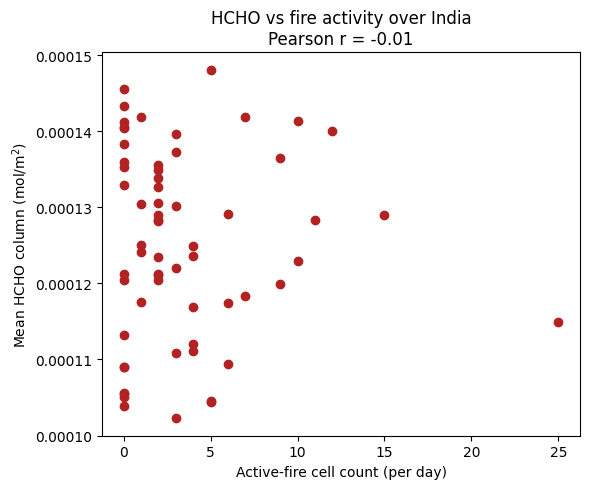

In [ ]:
"""
ISRO BAH 2026 - PS3, PHASE 3, STEP 2: HCHO hotspots + fire + wind (Objective 2).

Reads the HCHO, FIRE and wind (U10/V10) bands straight from the GeoTIFFs
(no model needed), flags HCHO hotspots as statistical anomalies, overlays
active fires and wind vectors, and shows the burning -> formaldehyde link.

Outputs:
    output/hcho_hotspots_<DATE>.png    map: HCHO + hotspots + fires + wind
    output/hcho_fire_corr.png          HCHO vs fire-count relationship
"""
import numpy as np, rasterio, os, glob, datetime as dt
import matplotlib.pyplot as plt

GRID_DIR = "data/gee_grid"
DATE = "2019-11-08"
EXTENT = [68.0, 98.0, 8.0, 37.0]
# band order in the GeoTIFF
B = {"NO2":0,"SO2":1,"CO":2,"O3":3,"HCHO":4,"AOD":5,"FIRE":6,
     "T2M":7,"D2M":8,"U10":9,"V10":10,"PRECIP":11}
os.makedirs("output", exist_ok=True)

def read(date):
    with rasterio.open(os.path.join(GRID_DIR, f"{date}.tif")) as ds:
        a = ds.read().astype("float32")
        if ds.nodata is not None: a[a == ds.nodata] = np.nan
    return a

a = read(DATE)
hcho = a[B["HCHO"]]; fire = a[B["FIRE"]]
u = a[B["U10"]]; v = a[B["V10"]]
H, W = hcho.shape

# ---- hotspot detection: HCHO above mean + 2*std (per-scene anomaly) ---------
mu, sd = np.nanmean(hcho), np.nanstd(hcho)
thresh = mu + 2*sd
hot = hcho > thresh
print(f"HCHO threshold (mean+2sd) = {thresh:.3e} mol/m^2; hotspot cells = {int(np.nansum(hot))}")

# ---- map -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(hcho, extent=EXTENT, origin="upper", cmap="YlOrRd")
plt.colorbar(im, ax=ax, shrink=0.8, label="HCHO column (mol/m$^2$)")

# hotspot outlines
ax.contour(hot.astype(float), levels=[0.5], colors="purple", linewidths=1.2,
           extent=EXTENT, origin="upper")

# active fires (FIRE band > 0) as points
yy, xx = np.where(fire > 0)
lon = EXTENT[0] + (xx + 0.5) * (EXTENT[1]-EXTENT[0]) / W
lat = EXTENT[3] - (yy + 0.5) * (EXTENT[3]-EXTENT[2]) / H
ax.scatter(lon, lat, s=6, c="black", marker="x", label="active fire", alpha=0.6)

# wind vectors (subsampled) -> shows transport direction
step = 8
Y, X = np.mgrid[0:H:step, 0:W:step]
glon = EXTENT[0] + (X + 0.5) * (EXTENT[1]-EXTENT[0]) / W
glat = EXTENT[3] - (Y + 0.5) * (EXTENT[3]-EXTENT[2]) / H
ax.quiver(glon, glat, u[::step, ::step], v[::step, ::step],
          color="steelblue", scale=200, width=0.002, alpha=0.7)

ax.set_title(f"HCHO Hotspots, Fires & Wind Transport - {DATE}\n"
             "purple = hotspot outline, x = fire, arrows = wind")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.savefig(f"output/hcho_hotspots_{DATE}.png", dpi=150)
print("Saved output/hcho_hotspots_%s.png" % DATE)

# ---- HCHO vs fire relationship across the whole season ---------------------
hv, fv = [], []
for f in sorted(glob.glob(os.path.join(GRID_DIR, "*.tif"))):
    arr = read(os.path.splitext(os.path.basename(f))[0])
    hv.append(np.nanmean(arr[B["HCHO"]]))
    fv.append(np.nansum(arr[B["FIRE"]] > 0))
hv, fv = np.array(hv), np.array(fv)
if len(hv) > 2 and np.nanstd(fv) > 0:
    r = np.corrcoef(fv, hv)[0, 1]
else:
    r = float("nan")
plt.figure(figsize=(6,5))
plt.scatter(fv, hv, c="firebrick")
plt.xlabel("Active-fire cell count (per day)")
plt.ylabel("Mean HCHO column (mol/m$^2$)")
plt.title(f"HCHO vs fire activity over India\nPearson r = {r:.2f}")
plt.tight_layout(); plt.savefig("output/hcho_fire_corr.png", dpi=150)
print(f"Saved output/hcho_fire_corr.png  (HCHO-fire correlation r = {r:.2f})")

In [ ]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")

  adding: data/gee_grid/ (stored 0%)
  adding: data/gee_grid/2024-10-17.tif (deflated 1%)
  adding: data/gee_grid/2019-10-22.tif (deflated 1%)
  adding: data/gee_grid/2024-11-04.tif (deflated 1%)
  adding: data/gee_grid/2024-10-16.tif (deflated 1%)
  adding: data/gee_grid/2019-11-07.tif (deflated 1%)
  adding: data/gee_grid/2024-11-13.tif (deflated 1%)
  adding: data/gee_grid/2024-11-12.tif (deflated 1%)
  adding: data/gee_grid/2024-10-31.tif (deflated 1%)
  adding: data/gee_grid/2019-10-28.tif (deflated 1%)
  adding: data/gee_grid/2019-10-16.tif (deflated 1%)
  adding: data/gee_grid/2019-11-01.tif (deflated 1%)
  adding: data/gee_grid/2019-11-05.tif (deflated 1%)
  adding: data/gee_grid/2024-10-27.tif (deflated 1%)
  adding: data/gee_grid/2019-11-11.tif (deflated 1%)
  adding: data/gee_grid/2024-10-19.tif (deflated 1%)
  adding: data/gee_grid/2024-10-24.tif (deflated 1%)
  adding: data/gee_grid/2024-10-30.tif (deflated 1%)
  adding: data/gee_grid/2019-10-29.tif (deflated 1%)
  adding:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip install geemap earthengine-api rasterio requests kaggle -q
import ee; ee.Authenticate(); ee.Initialize(project="isro-project-499507")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.9 MB/s eta 0:00:00


In [2]:
from google.colab import files; files.upload()     # pick isro_ps3_work.zip
!unzip -o isro_ps3_work.zip

Saving isro_ps3_work.zip to isro_ps3_work.zip
Archive:  isro_ps3_work.zip
   creating: data/gee_grid/
  inflating: data/gee_grid/2024-10-17.tif  
  inflating: data/gee_grid/2019-10-22.tif  
  inflating: data/gee_grid/2024-11-04.tif  
  inflating: data/gee_grid/2024-10-16.tif  
  inflating: data/gee_grid/2019-11-07.tif  
  inflating: data/gee_grid/2024-11-13.tif  
  inflating: data/gee_grid/2024-11-12.tif  
  inflating: data/gee_grid/2024-10-31.tif  
  inflating: data/gee_grid/2019-10-28.tif  
  inflating: data/gee_grid/2019-10-16.tif  
  inflating: data/gee_grid/2019-11-01.tif  
  inflating: data/gee_grid/2019-11-05.tif  
  inflating: data/gee_grid/2024-10-27.tif  
  inflating: data/gee_grid/2019-11-11.tif  
  inflating: data/gee_grid/2024-10-19.tif  
  inflating: data/gee_grid/2024-10-24.tif  
  inflating: data/gee_grid/2024-10-30.tif  
  inflating: data/gee_grid/2019-10-29.tif  
  inflating: data/gee_grid/2019-11-03.tif  
  inflating: data/gee_grid/2019-11-06.tif  
  inflating: data/

In [3]:
from google.colab import files; files.upload()     # pick kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rohanrao/air-quality-data-in-india -p data/cpcb --unzip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
License(s): CC0-1.0
100% 72.9M/72.9M [00:00<00:00, 123MB/s]



In [9]:
"""
ISRO BAH 2026 - Problem Statement 3
PHASE 1, STEP 1: Pull all gridded satellite + fire + meteorology predictors
from Google Earth Engine as daily, multi-band GeoTIFFs over an India grid.

RUN THIS IN GOOGLE COLAB (easiest) or any machine with the Earth Engine
Python API authenticated.

What it produces:
    data/gee_grid/YYYY-MM-DD.tif   (one multi-band GeoTIFF per day)
    Bands, in order:
        0 NO2     - tropospheric NO2 column        (mol/m^2)
        1 SO2     - SO2 column                      (mol/m^2)
        2 CO      - CO column                       (mol/m^2)
        3 O3      - O3 column                       (mol/m^2)
        4 HCHO    - tropospheric HCHO column        (mol/m^2)   <-- Obj 2
        5 AOD     - MODIS MAIAC AOD @550nm          (unitless, x0.001 applied)
        6 FIRE    - active-fire brightness T21      (Kelvin; proxy for fire) <-- Obj 2
        7 T2M     - 2 m air temperature             (K)
        8 D2M     - 2 m dewpoint temperature        (K)  -> RH computed later
        9 U10     - 10 m wind, eastward             (m/s)
       10 V10     - 10 m wind, northward            (m/s)
       11 PRECIP  - total precipitation (daily sum) (m)

These 12 bands are your model INPUT channels. Surface AQI labels come from
the separate script 02_fetch_ground_openaq.py (CPCB via OpenAQ).
"""

# ----------------------------------------------------------------------
# 0. SETUP  (in Colab, run these once)
#    !pip install geemap earthengine-api -q
# ----------------------------------------------------------------------
import ee, geemap, os, datetime as dt

# Put YOUR Earth Engine cloud project id here (from console.cloud.google.com)
EE_PROJECT = "isro-project-499507"

ee.Authenticate()                       # opens a browser / pastes a token
ee.Initialize(project=EE_PROJECT)

# ----------------------------------------------------------------------
# 1. CONFIG  -- start SMALL, then widen once it works
# ----------------------------------------------------------------------
# India bounding box (lon_min, lat_min, lon_max, lat_max)
REGION = ee.Geometry.Rectangle([68.0, 8.0, 98.0, 37.0])

START = "2019-10-01"      # crop-burning season; widen to full Oct-Feb later
END   = "2020-03-01"      # END is exclusive
SCALE = 27830             # ~0.25 deg in metres. Use 11132 for ~0.1 deg (heavier)

OUT_DIR = "data/gee_grid"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# 2. DAILY COMPOSITE BUILDERS
#    Each returns a single-band ee.Image (daily mean over the region),
#    cloud-masked where a cloud band exists.
# ----------------------------------------------------------------------
def _s5p(collection, band, d0, d1, cloud_max=0.5):
    sel = [band] + (["cloud_fraction"] if cloud_max is not None else [])
    col = (ee.ImageCollection(collection)
             .filterDate(d0, d1)
             .filterBounds(REGION)
             .select(sel))
    def mask(img):
        if cloud_max is not None:
            img = img.updateMask(img.select("cloud_fraction").lt(cloud_max))
        return img.select(band)
    return col.map(mask).mean().rename(band)

def daily_image(date):
    d0 = ee.Date(date)
    d1 = d0.advance(1, "day")

    no2  = _s5p("COPERNICUS/S5P/OFFL/L3_NO2",  "tropospheric_NO2_column_number_density",  d0, d1).rename("NO2")
    so2  = _s5p("COPERNICUS/S5P/OFFL/L3_SO2",  "SO2_column_number_density",               d0, d1).rename("SO2")
    co   = _s5p("COPERNICUS/S5P/OFFL/L3_CO",   "CO_column_number_density",                d0, d1, cloud_max=None).rename("CO")
    o3   = _s5p("COPERNICUS/S5P/OFFL/L3_O3",   "O3_column_number_density",                d0, d1, cloud_max=None).rename("O3")
    hcho = _s5p("COPERNICUS/S5P/OFFL/L3_HCHO", "tropospheric_HCHO_column_number_density", d0, d1).rename("HCHO")

    # MODIS MAIAC AOD @ 550 nm (multiple granules/day -> mean). scale factor 0.001.
    aod = (ee.ImageCollection("MODIS/061/MCD19A2_GRANULES")
             .filterDate(d0, d1).filterBounds(REGION)
             .select("Optical_Depth_055").mean().multiply(0.001).rename("AOD"))

    # FIRMS active fire brightness (T21). unmask 0 so "no fire" = 0, not masked.
    fire = (ee.ImageCollection("FIRMS")
              .filterDate(d0, d1).filterBounds(REGION)
              .select("T21").max().unmask(0).rename("FIRE"))

    # ERA5-Land daily aggregate meteorology
    era = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").filterDate(d0, d1).filterBounds(REGION).first()
    t2m    = era.select("temperature_2m").rename("T2M")
    d2m    = era.select("dewpoint_temperature_2m").rename("D2M")
    u10    = era.select("u_component_of_wind_10m").rename("U10")
    v10    = era.select("v_component_of_wind_10m").rename("V10")
    precip = era.select("total_precipitation_sum").rename("PRECIP")

    img = (no2.addBands([so2, co, o3, hcho, aod, fire, t2m, d2m, u10, v10, precip])
              .toFloat().clip(REGION))
    return img

# ----------------------------------------------------------------------
# 3. LOOP OVER DAYS AND DOWNLOAD
# ----------------------------------------------------------------------
def daterange(start, end):
    d = dt.date.fromisoformat(start)
    last = dt.date.fromisoformat(end)
    while d < last:
        yield d.isoformat()
        d += dt.timedelta(days=1)

if __name__ == "__main__":
    for date in daterange(START, END):
        out = os.path.join(OUT_DIR, f"{date}.tif")
        if os.path.exists(out):
            print("skip (exists):", date); continue
        try:
            img = daily_image(date)
            # Direct download (fine for a 0.25-deg India grid: tiny file).
            geemap.ee_export_image(img, filename=out, scale=SCALE,
                                   region=REGION, file_per_band=False)
            print("ok  :", date)
        except Exception as e:
            print("FAIL:", date, "->", repr(e))

    print("\nDone. GeoTIFFs in:", OUT_DIR)
    print("Inspect one with:  import rasterio; rasterio.open('<file>').read().shape")

skip (exists): 2019-10-01
skip (exists): 2019-10-02
skip (exists): 2019-10-03
skip (exists): 2019-10-04
skip (exists): 2019-10-05
skip (exists): 2019-10-06
skip (exists): 2019-10-07
skip (exists): 2019-10-08
skip (exists): 2019-10-09
skip (exists): 2019-10-10
skip (exists): 2019-10-11
skip (exists): 2019-10-12
skip (exists): 2019-10-13
skip (exists): 2019-10-14
skip (exists): 2019-10-15
skip (exists): 2019-10-16
skip (exists): 2019-10-17
skip (exists): 2019-10-18
skip (exists): 2019-10-19
skip (exists): 2019-10-20
skip (exists): 2019-10-21
skip (exists): 2019-10-22
skip (exists): 2019-10-23
skip (exists): 2019-10-24
skip (exists): 2019-10-25
skip (exists): 2019-10-26
skip (exists): 2019-10-27
skip (exists): 2019-10-28
skip (exists): 2019-10-29
skip (exists): 2019-10-30
skip (exists): 2019-10-31
skip (exists): 2019-11-01
skip (exists): 2019-11-02
skip (exists): 2019-11-03
skip (exists): 2019-11-04
skip (exists): 2019-11-05
skip (exists): 2019-11-06
skip (exists): 2019-11-07
skip (exists

In [8]:
"""
ISRO BAH 2026 - PS3, Phase 1, STEP 2 (v3)
Ground-truth labels from the CPCB historical dataset on Kaggle.
(We switched away from OpenAQ because it no longer carries Indian CPCB data.)

Dataset: rohanrao/air-quality-data-in-india  -> city_day.csv (CPCB, 2015-2020)
Window:  align with your satellite data (default Oct-Nov 2019).

SETUP IN COLAB (one time):
    1. kaggle.com -> your profile -> Settings -> "Create New API Token"
       (downloads kaggle.json)
    2. Run, then upload kaggle.json when prompted:

        !pip install kaggle -q
        from google.colab import files; files.upload()      # pick kaggle.json
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
        !kaggle datasets download -d rohanrao/air-quality-data-in-india -p data/cpcb --unzip

    3. Then run THIS script.

Output: data/ground_labels.csv
    columns: station_id, station, lat, lon, date, pm25, pm10, no2, so2, co, o3
"""
import pandas as pd, os, unicodedata

CITY_DAY = "data/cpcb/city_day.csv"
START = "2019-10-01"
END   = "2020-02-29"          # inclusive; match your GEE window
OUT   = "data"; os.makedirs(OUT, exist_ok=True)

# CPCB monitoring cities in this dataset -> (lat, lon).
CITY_LATLON = {
    "Ahmedabad": (23.03, 72.58), "Aizawl": (23.73, 92.72), "Amaravati": (16.57, 80.36),
    "Amritsar": (31.63, 74.87), "Bengaluru": (12.97, 77.59), "Bhopal": (23.26, 77.41),
    "Brajrajnagar": (21.82, 83.92), "Chandigarh": (30.73, 76.78), "Chennai": (13.08, 80.27),
    "Coimbatore": (11.02, 76.96), "Delhi": (28.61, 77.21), "Ernakulam": (9.98, 76.28),
    "Gurugram": (28.46, 77.03), "Guwahati": (26.14, 91.74), "Hyderabad": (17.38, 78.49),
    "Jaipur": (26.91, 75.79), "Jorapokhar": (23.71, 86.41), "Kochi": (9.93, 76.27),
    "Kolkata": (22.57, 88.36), "Lucknow": (26.85, 80.95), "Mumbai": (19.08, 72.88),
    "Patna": (25.59, 85.14), "Shillong": (25.58, 91.89), "Talcher": (20.95, 85.23),
    "Thiruvananthapuram": (8.52, 76.94), "Visakhapatnam": (17.69, 83.22),
}

df = pd.read_csv(CITY_DAY)
print("raw columns:", list(df.columns))

# keep our window
df["Date"] = pd.to_datetime(df["Date"])
df = df[(df["Date"] >= START) & (df["Date"] <= END)].copy()

# map dataset columns -> our schema (CPCB CO is already mg/m3)
ren = {"PM2.5": "pm25", "PM10": "pm10", "NO2": "no2",
       "SO2": "so2", "CO": "co", "O3": "o3"}
df = df.rename(columns=ren)

rows = []
for _, r in df.iterrows():
    city = r["City"]
    if city not in CITY_LATLON:
        continue
    lat, lon = CITY_LATLON[city]
    rows.append({
        "station_id": city.lower().replace(" ", "_"),
        "station": city, "lat": lat, "lon": lon,
        "date": r["Date"].date().isoformat(),
        "pm25": r.get("pm25"), "pm10": r.get("pm10"), "no2": r.get("no2"),
        "so2": r.get("so2"), "co": r.get("co"), "o3": r.get("o3"),
    })

out = pd.DataFrame(rows, columns=["station_id","station","lat","lon","date",
                                  "pm25","pm10","no2","so2","co","o3"])
path = os.path.join(OUT, "ground_labels.csv")
out.to_csv(path, index=False)
print(f"\nWrote {path}")
print(f"  {len(out)} city-day label rows, {out['station'].nunique()} cities")
print(out.head(8).to_string(index=False))

raw columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Wrote data/ground_labels.csv
  3574 city-day label rows, 25 cities
station_id   station   lat   lon       date  pm25   pm10    no2    so2    co    o3
 ahmedabad Ahmedabad 23.03 72.58 2019-10-01 33.66  56.01  92.52 137.97 11.85 72.52
 ahmedabad Ahmedabad 23.03 72.58 2019-10-02 51.11 106.20 118.26 129.38 21.47 41.28
 ahmedabad Ahmedabad 23.03 72.58 2019-10-03 57.08 126.90  98.77  99.59 18.90 43.21
 ahmedabad Ahmedabad 23.03 72.58 2019-10-04 49.88 127.47 101.30 120.80 25.05 48.48
 ahmedabad Ahmedabad 23.03 72.58 2019-10-05 57.65 138.99 168.74 153.44 49.58 41.05
 ahmedabad Ahmedabad 23.03 72.58 2019-10-06 68.62 117.69 132.77 158.04 55.22 68.56
 ahmedabad Ahmedabad 23.03 72.58 2019-10-07 99.81 155.39 162.56 146.33 36.34 68.81
 ahmedabad Ahmedabad 23.03 72.58 2019-10-08 73.52 153.75 171.17 154.99 45.99 70.66


In [10]:
!ls data/gee_grid/*.tif | wc -l
!wc -l data/ground_labels.csv
!ls models output


183
3575 data/ground_labels.csv
models:
cnn_lstm.keras	scalers.npz

output:
aqi_grid_2019-11-08.npy  hcho_fire_corr.png
aqi_map_2019-11-08.png	 hcho_hotspots_2019-11-08.png


In [11]:
"""
ISRO BAH 2026 - PS3, PHASE 2, STEP 1: Build the training table.

For every CPCB label (city, date) we extract from the satellite GeoTIFFs:
  - a KxK spatial PATCH of all 12 bands, centred on the city
  - over the previous T days (so the LSTM sees a time sequence)
That patch-sequence is the INPUT (X); the city's surface pollutants are the TARGET (y).

Output: data/train.npz  with
    X     float32 (N, T, K, K, 12)   model inputs
    Y     float32 (N, 5)             targets [pm25, no2, so2, co, o3]
    meta  (N, 2) strings             [city, date] for traceability
    target_names, band_names

Needs: rasterio, numpy, pandas  (already installed in your Colab).
"""
import numpy as np, pandas as pd, rasterio, os, datetime as dt

GRID_DIR = "data/gee_grid"
LABELS   = "data/ground_labels.csv"
OUT      = "data/train.npz"

T = 5            # days of history per sample (the LSTM time dimension)
K = 5            # patch size KxK (spatial context for the CNN); must be odd
TARGETS = ["pm25", "no2", "so2", "co", "o3"]   # surface values we predict
BANDS = ["NO2","SO2","CO","O3","HCHO","AOD","FIRE","T2M","D2M","U10","V10","PRECIP"]

# ---- helpers ---------------------------------------------------------------
def tif_path(date):
    return os.path.join(GRID_DIR, f"{date}.tif")

def load_day(date, pad):
    """Return an edge-padded (12, H+2pad, W+2pad) array for one day, or None."""
    p = tif_path(date)
    if not os.path.exists(p):
        return None
    with rasterio.open(p) as ds:
        arr = ds.read().astype("float32")               # (12, H, W)
        arr[arr == ds.nodata] = np.nan if ds.nodata is not None else arr
    return np.pad(arr, ((0,0),(pad,pad),(pad,pad)), mode="edge")

def rowcol(lat, lon):
    """Pixel row/col of a lat/lon in the grid (same for every daily tif)."""
    with rasterio.open(tif_path_any()) as ds:
        r, c = ds.index(lon, lat)
    return r, c

def tif_path_any():
    for f in sorted(os.listdir(GRID_DIR)):
        if f.endswith(".tif"):
            return os.path.join(GRID_DIR, f)
    raise FileNotFoundError("No GeoTIFFs in " + GRID_DIR)

# ---- build -----------------------------------------------------------------
df = pd.read_csv(LABELS)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df.dropna(subset=["pm25"])          # need at least PM2.5 as anchor target
pad = K // 2

# cache padded daily arrays so we only read each tif once
cache = {}
def get_day(date):
    if date not in cache:
        cache[date] = load_day(date, pad)
    return cache[date]

X, Y, meta = [], [], []
skipped = 0
for _, row in df.iterrows():
    d0 = row["date"]
    days = [(d0 - dt.timedelta(days=k)).isoformat() for k in range(T-1, -1, -1)]  # oldest->newest
    arrs = [get_day(dd) for dd in days]
    if any(a is None for a in arrs):     # missing a day in the window
        skipped += 1; continue
    r, c = rowcol(row["lat"], row["lon"])
    rp, cp = r + pad, c + pad            # shift for padding
    seq = []
    for a in arrs:
        patch = a[:, rp-pad:rp+pad+1, cp-pad:cp+pad+1]   # (12, K, K)
        seq.append(np.transpose(patch, (1, 2, 0)))       # (K, K, 12)
    X.append(np.stack(seq, axis=0))                      # (T, K, K, 12)
    Y.append([row.get(t, np.nan) for t in TARGETS])
    meta.append([row["station"], d0.isoformat()])

X = np.asarray(X, dtype="float32")
Y = np.asarray(Y, dtype="float32")
meta = np.asarray(meta)

# fill remaining predictor gaps (clouds) with per-band median
for b in range(X.shape[-1]):
    med = np.nanmedian(X[..., b])
    X[..., b] = np.nan_to_num(X[..., b], nan=med)

# fill missing non-PM targets with column median (PM2.5 already non-null)
for j in range(Y.shape[1]):
    col = Y[:, j]
    med = np.nanmedian(col)
    Y[:, j] = np.where(np.isnan(col), med, col)

np.savez_compressed(OUT, X=X, Y=Y, meta=meta,
                    target_names=np.array(TARGETS), band_names=np.array(BANDS))
print(f"Saved {OUT}")
print(f"  X shape {X.shape}  (samples, days, patch, patch, bands)")
print(f"  Y shape {Y.shape}  targets={TARGETS}")
print(f"  samples kept: {len(X)}   skipped (incomplete window): {skipped}")
print(f"  cities: {len(set(meta[:,0]))}   date span: {meta[:,1].min()} -> {meta[:,1].max()}")

Saved data/train.npz
  X shape (3418, 5, 5, 5, 12)  (samples, days, patch, patch, bands)
  Y shape (3418, 5)  targets=['pm25', 'no2', 'so2', 'co', 'o3']
  samples kept: 3418   skipped (incomplete window): 84


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U18'), dtype('<U18')) -> None

In [12]:
import numpy as np
d = np.load("data/train.npz", allow_pickle=True)
print("X", d["X"].shape, "  Y", d["Y"].shape)
print("samples:", len(d["X"]), "  cities:", len(set(d["meta"][:,0])))

X (3418, 5, 5, 5, 12)   Y (3418, 5)
samples: 3418   cities: 25


In [13]:
"""
ISRO BAH 2026 - PS3, PHASE 2, STEP 2: Train the CNN-LSTM (Objective 1).

Reads data/train.npz, trains a CNN-LSTM that maps a patch-sequence of
satellite+met bands -> surface pollutant concentrations, and validates on
HELD-OUT CITIES (the real test: can it predict where there is NO monitor?).

Saves:
    models/cnn_lstm.keras     trained model
    models/scalers.npz        normalisation stats (needed for Phase 3 maps)

Needs: tensorflow (preinstalled in Colab), numpy, scikit-learn.
"""
import numpy as np, os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, r2_score

DATA = "data/train.npz"
os.makedirs("models", exist_ok=True)
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

d = np.load(DATA, allow_pickle=True)
X, Y, meta = d["X"], d["Y"], d["meta"]
TARGETS = list(d["target_names"])
N, T, K, _, C = X.shape
print("X", X.shape, "Y", Y.shape, "targets", TARGETS)

# ---- split by CITY (spatial hold-out) --------------------------------------
cities = np.array(sorted(set(meta[:, 0])))
rng = np.random.default_rng(SEED); rng.shuffle(cities)
n_val = max(3, int(0.25 * len(cities)))
val_cities = set(cities[:n_val])
is_val = np.array([c in val_cities for c in meta[:, 0]])
print(f"{len(cities)} cities -> {n_val} held out for validation: {sorted(val_cities)}")

Xtr, Ytr = X[~is_val], Y[~is_val]
Xva, Yva = X[is_val],  Y[is_val]

# ---- normalise -------------------------------------------------------------
xmean = Xtr.reshape(-1, C).mean(0); xstd = Xtr.reshape(-1, C).std(0) + 1e-6
def nx(a): return (a - xmean) / xstd
ymean = Ytr.mean(0); ystd = Ytr.std(0) + 1e-6
def ny(a): return (a - ymean) / ystd
def iy(a): return a * ystd + ymean        # invert -> real concentrations

Xtr_n, Xva_n = nx(Xtr), nx(Xva)
Ytr_n, Yva_n = ny(Ytr), ny(Yva)

# ---- model -----------------------------------------------------------------
inp = layers.Input((T, K, K, C))
x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(inp)
x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(x)
x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)   # (T, 32)
x = layers.LSTM(64)(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(len(TARGETS))(x)
model = models.Model(inp, out)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

es = callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")
hist = model.fit(Xtr_n, Ytr_n, validation_data=(Xva_n, Yva_n),
                 epochs=200, batch_size=32, callbacks=[es], verbose=2)

# ---- evaluate on held-out cities (real concentration units) ----------------
pred = iy(model.predict(Xva_n, verbose=0))
pred = np.clip(pred, 0, None)
print("\n=== Validation on held-out cities (real units) ===")
for j, t in enumerate(TARGETS):
    mae = mean_absolute_error(Yva[:, j], pred[:, j])
    r2  = r2_score(Yva[:, j], pred[:, j])
    print(f"  {t:5s}  MAE={mae:8.2f}   R2={r2:6.3f}")
print("  (PM2.5 is the most reliable metric; other targets had some imputed values.)")

model.save("models/cnn_lstm.keras")
np.savez("models/scalers.npz", xmean=xmean, xstd=xstd, ymean=ymean, ystd=ystd,
         target_names=np.array(TARGETS))
print("\nSaved models/cnn_lstm.keras and models/scalers.npz")

X (3418, 5, 5, 5, 12) Y (3418, 5) targets [np.str_('pm25'), np.str_('no2'), np.str_('so2'), np.str_('co'), np.str_('o3')]
25 cities -> 6 held out for validation: [np.str_('Chennai'), np.str_('Delhi'), np.str_('Jorapokhar'), np.str_('Kochi'), np.str_('Mumbai'), np.str_('Patna')]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 5, 5, 12)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 5, 5, 32)    │         3,488 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 5, 5, 32)    │         9,248 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,053 (164.27 KB)

 Trainable params: 42,053 (164.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
83/83 - 7s - 87ms/step - loss: 0.8326 - mae: 0.5182 - val_loss: 0.7791 - val_mae: 0.5910
Epoch 2/200
83/83 - 3s - 40ms/step - loss: 0.6201 - mae: 0.4595 - val_loss: 0.7787 - val_mae: 0.5865
Epoch 3/200
83/83 - 4s - 49ms/step - loss: 0.5046 - mae: 0.4181 - val_loss: 0.7998 - val_mae: 0.5971
Epoch 4/200
83/83 - 2s - 27ms/step - loss: 0.4241 - mae: 0.3858 - val_loss: 0.8102 - val_mae: 0.6002
Epoch 5/200
83/83 - 2s - 27ms/step - loss: 0.3867 - mae: 0.3676 - val_loss: 0.8201 - val_mae: 0.5895
Epoch 6/200
83/83 - 3s - 34ms/step - loss: 0.3557 - mae: 0.3568 - val_loss: 0.8154 - val_mae: 0.5872
Epoch 7/200
83/83 - 3s - 37ms/step - loss: 0.3329 - mae: 0.3454 - val_loss: 0.7863 - val_mae: 0.5786
Epoch 8/200
83/83 - 2s - 27ms/step - loss: 0.3096 - mae: 0.3349 - val_loss: 0.7416 - val_mae: 0.5564
Epoch 9/200
83/83 - 2s - 27ms/step - loss: 0.3039 - mae: 0.3300 - val_loss: 0.7722 - val_mae: 0.5703
Epoch 10/200
83/83 - 2s - 27ms/step - loss: 0.2831 - mae: 0.3227 - val_loss: 0.7642 - val_m

Using 152 daily files from 2019-10-01 to 2020-02-29


fire-active cells: 25
mean local corr by lag: {0: 0.133, 1: 0.186, 2: 0.134, 3: 0.103}
strongest at lag = 1 day(s), r = 0.186
mean HCHO  high-fire cells = 1.598e-04   no-fire cells = 1.075e-04
Saved 3 figures to output/


/tmp/ipykernel_2477/1626403590.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hcho_mean[lo][~np.isnan(hcho_mean[lo])],


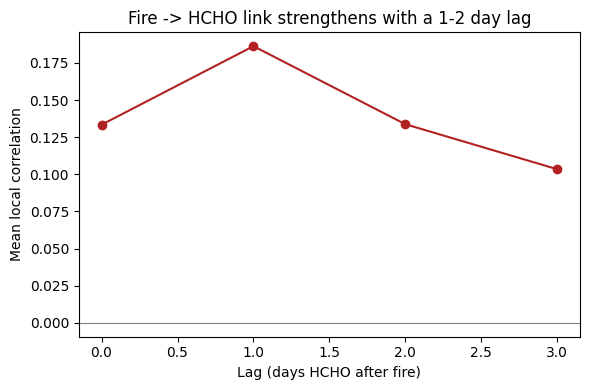

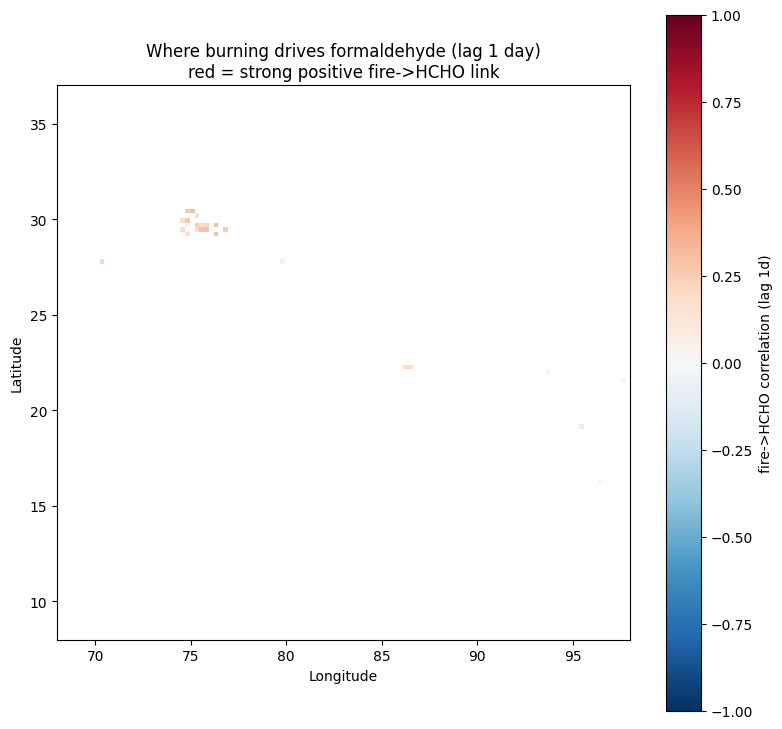

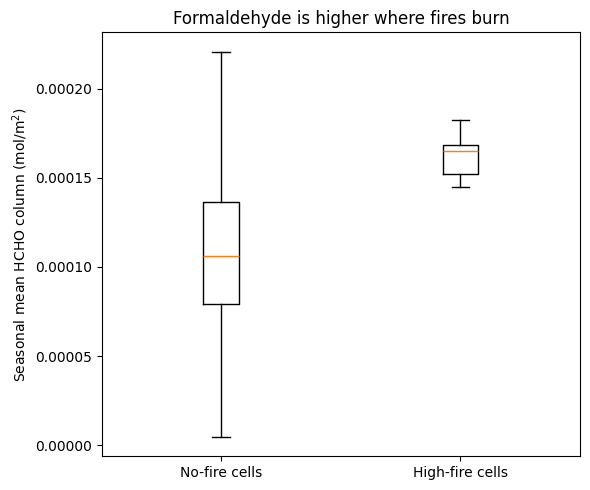

In [16]:
"""
ISRO BAH 2026 - PS3, PHASE 3 (refined): proper fire -> HCHO link (Objective 2).

Yesterday's flat r = -0.01 compared a NATIONAL daily average of HCHO to a
national fire count - too coarse. The real fire->formaldehyde signal is:
  (a) LOCAL  - it shows up in the same/neighbouring cells, not nationwide
  (b) LAGGED - HCHO forms a day or two AFTER the fire, downwind
This script measures it correctly and produces three clear results.

Outputs:
    output/fire_hcho_lag.png        mean local correlation vs lag (0-3 days)
    output/fire_hcho_corrmap.png    where the fire->HCHO link is strongest
    output/fire_hcho_compare.png    HCHO over high-fire vs no-fire cells
"""
import numpy as np, rasterio, os, glob, datetime as dt
import matplotlib.pyplot as plt

GRID = "data/gee_grid"
EXTENT = [68.0, 98.0, 8.0, 37.0]
B = {"HCHO": 4, "FIRE": 6}
START, END = dt.date(2019, 10, 1), dt.date(2020, 3, 1)   # season only (skip stray 2024 tifs)
os.makedirs("output", exist_ok=True)

# ---- load the season's HCHO and fire stacks --------------------------------
files = []
for f in sorted(glob.glob(os.path.join(GRID, "*.tif"))):
    name = os.path.splitext(os.path.basename(f))[0]
    try:
        d = dt.date.fromisoformat(name)
    except ValueError:
        continue
    if START <= d < END:
        files.append((d, f))
files.sort()
print(f"Using {len(files)} daily files from {files[0][0]} to {files[-1][0]}")

hcho, fire = [], []
for d, f in files:
    with rasterio.open(f) as ds:
        a = ds.read().astype("float32")
        if ds.nodata is not None:
            a[a == ds.nodata] = np.nan
    a[np.abs(a) > 1e30] = np.nan          # kill float32-max no-data sentinels
    hcho.append(a[B["HCHO"]])
    fire.append((np.nan_to_num(a[B["FIRE"]], nan=0.0) > 0).astype("float32"))  # fire presence
hcho = np.array(hcho); fire = np.array(fire)             # (T, H, W)
T, H, W = hcho.shape

# fill HCHO cloud gaps with each day's spatial median so corr is defined
for t in range(T):
    m = np.nanmedian(hcho[t])
    hcho[t] = np.nan_to_num(hcho[t], nan=m)

def pearson_axis0(x, y):
    xm = x - x.mean(0); ym = y - y.mean(0)
    num = (xm * ym).sum(0)
    den = np.sqrt((xm**2).sum(0) * (ym**2).sum(0)) + 1e-9
    return num / den

# only analyse cells that actually saw fire (>=3 fire-days over the season)
fire_season = fire.sum(0)
active = fire_season >= 3
print(f"fire-active cells: {int(active.sum())}")

# ---- (1) correlation vs lag -------------------------------------------------
lags = [0, 1, 2, 3]
mean_corr = []
for lag in lags:
    f = fire if lag == 0 else fire[:-lag]
    h = hcho if lag == 0 else hcho[lag:]
    c = pearson_axis0(f, h)
    mean_corr.append(float(np.nanmean(c[active])))
best = int(np.argmax(mean_corr))
print("mean local corr by lag:", {l: round(c,3) for l,c in zip(lags, mean_corr)})
print(f"strongest at lag = {lags[best]} day(s), r = {mean_corr[best]:.3f}")

plt.figure(figsize=(6,4))
plt.plot(lags, mean_corr, "o-", color="firebrick")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("Lag (days HCHO after fire)"); plt.ylabel("Mean local correlation")
plt.title("Fire -> HCHO link strengthens with a 1-2 day lag")
plt.tight_layout(); plt.savefig("output/fire_hcho_lag.png", dpi=150)

# ---- (2) correlation map at the best lag -----------------------------------
lag = lags[best]
f = fire if lag == 0 else fire[:-lag]
h = hcho if lag == 0 else hcho[lag:]
cmap_corr = pearson_axis0(f, h)
cmap_corr[~active] = np.nan
plt.figure(figsize=(8,9))
im = plt.imshow(cmap_corr, extent=EXTENT, origin="upper", cmap="RdBu_r",
                vmin=-1, vmax=1)
plt.colorbar(im, shrink=0.8, label=f"fire->HCHO correlation (lag {lag}d)")
plt.title(f"Where burning drives formaldehyde (lag {lag} day)\n"
          "red = strong positive fire->HCHO link")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.savefig("output/fire_hcho_corrmap.png", dpi=150)

# ---- (3) HCHO over high-fire vs no-fire cells ------------------------------
hcho_mean = np.nanmean(hcho, 0)
hi = fire_season >= np.percentile(fire_season[fire_season > 0], 90) if (fire_season>0).any() else active
lo = fire_season == 0
print(f"mean HCHO  high-fire cells = {np.nanmean(hcho_mean[hi]):.3e}   "
      f"no-fire cells = {np.nanmean(hcho_mean[lo]):.3e}")
plt.figure(figsize=(6,5))
plt.boxplot([hcho_mean[lo][~np.isnan(hcho_mean[lo])],
             hcho_mean[hi][~np.isnan(hcho_mean[hi])]],
            labels=["No-fire cells", "High-fire cells"], showfliers=False)
plt.ylabel("Seasonal mean HCHO column (mol/m$^2$)")
plt.title("Formaldehyde is higher where fires burn")
plt.tight_layout(); plt.savefig("output/fire_hcho_compare.png", dpi=150)
print("Saved 3 figures to output/")

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step
Saved output/aqi_map_2019-11-08.png
AQI range: 19 - 427  mean: 88


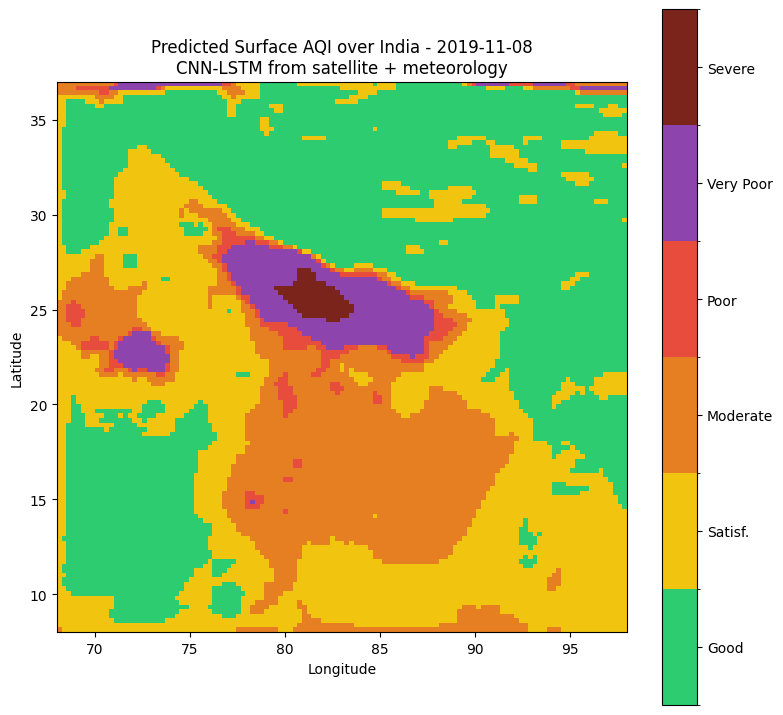

In [15]:
"""
ISRO BAH 2026 - PS3, PHASE 3, STEP 1: National surface-AQI heatmap (Objective 1).

Runs the trained CNN-LSTM over EVERY grid cell in India for one date, converts
the predicted pollutants to CPCB AQI, and renders a heatmap over the country.

Output: output/aqi_map_<DATE>.png   and   output/aqi_grid_<DATE>.npy

Needs: tensorflow, numpy, rasterio, matplotlib.
"""
import numpy as np, rasterio, os, datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from numpy.lib.stride_tricks import sliding_window_view

GRID_DIR = "data/gee_grid"
DATE = "2019-11-08"      # a peak-burning day; change to any date you downloaded
T, K = 5, 5
EXTENT = [68.0, 98.0, 8.0, 37.0]     # lon_min, lon_max, lat_min, lat_max
os.makedirs("output", exist_ok=True)

# ---- CPCB AQI from the 5 predicted pollutants (vectorised) -----------------
IP = [0, 50, 100, 200, 300, 400, 500]
CP = {  # concentration breakpoints (CO in mg/m3, rest ug/m3)
 "pm25":[0,30,60,90,120,250,500], "no2":[0,40,80,180,280,400,1000],
 "so2":[0,40,80,380,800,1600,2620], "co":[0,1,2,10,17,34,50],
 "o3":[0,50,100,168,208,748,1000]}
def aqi_from(pred, names):
    subs = [np.interp(pred[..., j], CP[t], IP) for j, t in enumerate(names)]
    return np.max(np.stack(subs, -1), -1)     # worst-pollutant rule

# ---- load model + scalers --------------------------------------------------
model = tf.keras.models.load_model("models/cnn_lstm.keras")
s = np.load("models/scalers.npz", allow_pickle=True)
xmean, xstd, ymean, ystd = s["xmean"], s["xstd"], s["ymean"], s["ystd"]
TARGETS = list(s["target_names"])

# ---- build the patch-sequence for every pixel ------------------------------
def day_array(date):
    p = os.path.join(GRID_DIR, f"{date}.tif")
    with rasterio.open(p) as ds:
        a = ds.read().astype("float32")           # (C, H, W)
        if ds.nodata is not None: a[a == ds.nodata] = np.nan
    return a

d0 = dt.date.fromisoformat(DATE)
days = [(d0 - dt.timedelta(days=k)).isoformat() for k in range(T-1, -1, -1)]
stack = [day_array(dd) for dd in days]            # list of (C,H,W)
C, H, W = stack[0].shape
pad = K // 2

seq = np.empty((H*W, T, K, K, C), dtype="float32")
for ti, a in enumerate(stack):
    a = np.transpose(a, (1, 2, 0))                # (H, W, C)
    a = np.pad(a, ((pad,pad),(pad,pad),(0,0)), mode="edge")
    win = sliding_window_view(a, (K, K), axis=(0, 1))  # (H, W, C, K, K)
    win = np.transpose(win, (0, 1, 3, 4, 2)).reshape(H*W, K, K, C)
    seq[:, ti] = win

# normalise (NaN -> mean -> 0 after z-score)
seq = (seq - xmean) / xstd
seq = np.nan_to_num(seq, nan=0.0)

# ---- predict over the whole grid -------------------------------------------
pred = model.predict(seq, batch_size=2048, verbose=1)
pred = pred * ystd + ymean
pred = np.clip(pred, 0, None)
aqi = aqi_from(pred, TARGETS).reshape(H, W)
np.save(f"output/aqi_grid_{DATE}.npy", aqi)

# ---- plot ------------------------------------------------------------------
bounds = [0, 50, 100, 200, 300, 400, 500]
colors = ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C", "#8E44AD", "#7B241C"]
cmap = ListedColormap(colors); norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8, 9))
im = plt.imshow(aqi, extent=EXTENT, origin="upper", cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[25,75,150,250,350,450], shrink=0.8)
cbar.ax.set_yticklabels(["Good","Satisf.","Moderate","Poor","Very Poor","Severe"])
plt.title(f"Predicted Surface AQI over India - {DATE}\nCNN-LSTM from satellite + meteorology")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"output/aqi_map_{DATE}.png", dpi=150)
print("Saved output/aqi_map_%s.png" % DATE)
print("AQI range:", int(np.nanmin(aqi)), "-", int(np.nanmax(aqi)),
      " mean:", int(np.nanmean(aqi)))

Saved output/fire_hcho_map_clean.png
active cells=25, mean corr (lag 1)=0.186


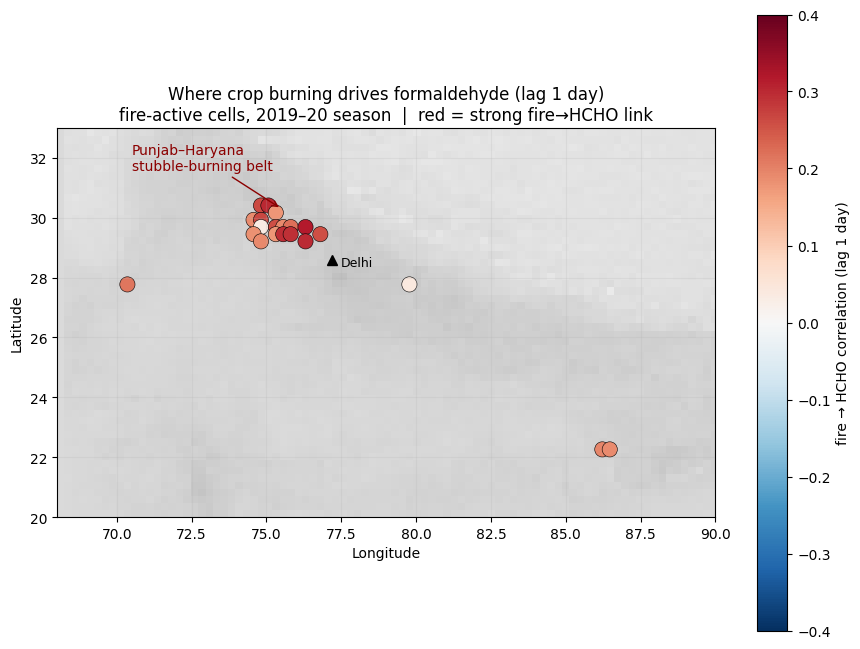

In [17]:
"""
ISRO BAH 2026 - PS3: presentation-ready fire->HCHO correlation map (Objective 2).
Re-reads the season, computes the lag-1 fire->HCHO correlation, and draws a
clean, zoomed map of the north-India burning belt with labelled regions.

Output: output/fire_hcho_map_clean.png
"""
import numpy as np, rasterio, os, glob, datetime as dt
import matplotlib.pyplot as plt

GRID = "data/gee_grid"
EXTENT = [68.0, 98.0, 8.0, 37.0]
B = {"HCHO": 4, "FIRE": 6}
START, END = dt.date(2019, 10, 1), dt.date(2020, 3, 1)
LAG = 1                      # peak lag found in step 07
os.makedirs("output", exist_ok=True)

# ---- load season HCHO + fire (with no-data handling) -----------------------
files = []
for f in sorted(glob.glob(os.path.join(GRID, "*.tif"))):
    n = os.path.splitext(os.path.basename(f))[0]
    try: d = dt.date.fromisoformat(n)
    except ValueError: continue
    if START <= d < END: files.append((d, f))
files.sort()

hcho, fire = [], []
for d, f in files:
    with rasterio.open(f) as ds:
        a = ds.read().astype("float32")
        if ds.nodata is not None: a[a == ds.nodata] = np.nan
    a[np.abs(a) > 1e30] = np.nan
    hcho.append(a[B["HCHO"]])
    fire.append((np.nan_to_num(a[B["FIRE"]], nan=0.0) > 0).astype("float32"))
hcho = np.array(hcho); fire = np.array(fire)
T, H, W = hcho.shape
for t in range(T):
    hcho[t] = np.nan_to_num(hcho[t], nan=np.nanmedian(hcho[t]))

# ---- lag-1 correlation on fire-active cells --------------------------------
def pearson0(x, y):
    xm = x - x.mean(0); ym = y - y.mean(0)
    return (xm*ym).sum(0) / (np.sqrt((xm**2).sum(0)*(ym**2).sum(0)) + 1e-9)

fseason = fire.sum(0)
active = fseason >= 3
c = pearson0(fire[:-LAG], hcho[LAG:])

# ---- cell centre lon/lat of active cells -----------------------------------
rows, cols = np.where(active)
lon = EXTENT[0] + (cols + 0.5) * (EXTENT[1]-EXTENT[0]) / W
lat = EXTENT[3] - (rows + 0.5) * (EXTENT[3]-EXTENT[2]) / H
corr = c[rows, cols]

# ---- plot ------------------------------------------------------------------
hcho_bg = np.nanmean(hcho, 0)
fig, ax = plt.subplots(figsize=(9, 8))
# faint HCHO context background
ax.imshow(hcho_bg, extent=EXTENT, origin="upper", cmap="Greys", alpha=0.25)
# fire-active cells coloured by fire->HCHO correlation
sc = ax.scatter(lon, lat, c=corr, cmap="RdBu_r", vmin=-0.4, vmax=0.4,
                s=120, edgecolor="k", linewidth=0.4)
cb = fig.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label(f"fire → HCHO correlation (lag {LAG} day)")

# zoom to the action (north India)
ax.set_xlim(68, 90); ax.set_ylim(20, 33)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Where crop burning drives formaldehyde (lag 1 day)\n"
             "fire-active cells, 2019–20 season  |  red = strong fire→HCHO link")

# region annotations
ax.annotate("Punjab–Haryana\nstubble-burning belt", xy=(75.5, 30.3),
            xytext=(70.5, 31.6), fontsize=10, color="darkred",
            arrowprops=dict(arrowstyle="->", color="darkred"))
ax.plot(77.2, 28.6, "k^", ms=7); ax.text(77.5, 28.4, "Delhi", fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig("output/fire_hcho_map_clean.png", dpi=160)
print("Saved output/fire_hcho_map_clean.png")
print(f"active cells={int(active.sum())}, mean corr (lag {LAG})={np.nanmean(corr):.3f}")

In [18]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")


updating: data/gee_grid/ (stored 0%)
updating: data/gee_grid/2024-10-17.tif (deflated 1%)
updating: data/gee_grid/2019-10-22.tif (deflated 1%)
updating: data/gee_grid/2024-11-04.tif (deflated 1%)
updating: data/gee_grid/2024-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-07.tif (deflated 1%)
updating: data/gee_grid/2024-11-13.tif (deflated 1%)
updating: data/gee_grid/2024-11-12.tif (deflated 1%)
updating: data/gee_grid/2024-10-31.tif (deflated 1%)
updating: data/gee_grid/2019-10-28.tif (deflated 1%)
updating: data/gee_grid/2019-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-01.tif (deflated 1%)
updating: data/gee_grid/2019-11-05.tif (deflated 1%)
updating: data/gee_grid/2024-10-27.tif (deflated 1%)
updating: data/gee_grid/2019-11-11.tif (deflated 1%)
updating: data/gee_grid/2024-10-19.tif (deflated 1%)
updating: data/gee_grid/2024-10-24.tif (deflated 1%)
updating: data/gee_grid/2024-10-30.tif (deflated 1%)
updating: data/gee_grid/2019-10-29.tif (deflated 1%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
"""
ISRO BAH 2026 - PS3, gas fix (1/2): build training table that KEEPS missing
gas readings as NaN (a mask) instead of median-filling them.

Same as 03, but:
  - keeps a row if it has AT LEAST ONE real target (not just PM2.5)
  - does NOT fill missing targets -> they stay NaN so the trainer can ignore them

Output: data/train_masked.npz  (X, Y-with-NaNs, meta)
"""
import numpy as np, pandas as pd, rasterio, os, datetime as dt

GRID_DIR = "data/gee_grid"; LABELS = "data/ground_labels.csv"
OUT = "data/train_masked.npz"
T, K = 5, 5
TARGETS = ["pm25", "no2", "so2", "co", "o3"]
BANDS = ["NO2","SO2","CO","O3","HCHO","AOD","FIRE","T2M","D2M","U10","V10","PRECIP"]

def tif_path_any():
    for f in sorted(os.listdir(GRID_DIR)):
        if f.endswith(".tif"): return os.path.join(GRID_DIR, f)
    raise FileNotFoundError("no tifs")

def load_day(date, pad):
    p = os.path.join(GRID_DIR, f"{date}.tif")
    if not os.path.exists(p): return None
    with rasterio.open(p) as ds:
        a = ds.read().astype("float32")
        if ds.nodata is not None: a[a == ds.nodata] = np.nan
    a[np.abs(a) > 1e30] = np.nan
    return np.pad(a, ((0,0),(pad,pad),(pad,pad)), mode="edge")

df = pd.read_csv(LABELS)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df.dropna(subset=TARGETS, how="all")          # keep rows with >=1 real target
pad = K // 2

with rasterio.open(tif_path_any()) as ds0:
    def rc(lat, lon): return ds0.index(lon, lat)

cache = {}
def get_day(d):
    if d not in cache: cache[d] = load_day(d, pad)
    return cache[d]

X, Y, meta, skipped = [], [], [], 0
for _, row in df.iterrows():
    d0 = row["date"]
    days = [(d0 - dt.timedelta(days=k)).isoformat() for k in range(T-1, -1, -1)]
    arrs = [get_day(dd) for dd in days]
    if any(a is None for a in arrs): skipped += 1; continue
    r, c = rc(row["lat"], row["lon"]); rp, cp = r+pad, c+pad
    seq = [np.transpose(a[:, rp-pad:rp+pad+1, cp-pad:cp+pad+1], (1,2,0)) for a in arrs]
    X.append(np.stack(seq, 0))
    Y.append([row.get(t, np.nan) for t in TARGETS])    # NaN kept where missing
    meta.append([row["station"], d0.isoformat()])

X = np.asarray(X, "float32"); Y = np.asarray(Y, "float32"); meta = np.asarray(meta)

# fill ONLY predictor gaps (clouds); leave target NaNs alone
for b in range(X.shape[-1]):
    X[..., b] = np.nan_to_num(X[..., b], nan=np.nanmedian(X[..., b]))

np.savez_compressed(OUT, X=X, Y=Y, meta=meta,
                    target_names=np.array(TARGETS), band_names=np.array(BANDS))
print("Saved", OUT)
print("X", X.shape, " Y", Y.shape, " samples", len(X), " skipped", skipped)
realpct = 100*np.mean(~np.isnan(Y), 0)
print("real (non-missing) % per target:", {t: round(p,1) for t,p in zip(TARGETS, realpct)})

Saved data/train_masked.npz
X (3437, 5, 5, 5, 12)  Y (3437, 5)  samples 3437  skipped 86
real (non-missing) % per target: {'pm25': np.float64(99.4), 'no2': np.float64(99.1), 'so2': np.float64(99.5), 'co': np.float64(95.7), 'o3': np.float64(97.9)}


In [20]:
"""
ISRO BAH 2026 - PS3, gas fix (2/2): train the CNN-LSTM with a MASKED loss so
missing gas readings are ignored. The model only learns from, and is scored on,
REAL CPCB measurements.

Reads data/train_masked.npz. Saves models/cnn_lstm_masked.keras + scalers_masked.npz.
"""
import numpy as np, os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, r2_score

d = np.load("data/train_masked.npz", allow_pickle=True)
X, Y, meta = d["X"], d["Y"], d["meta"]
TARGETS = list(d["target_names"]); N, T, K, _, C = X.shape
os.makedirs("models", exist_ok=True)
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
print("X", X.shape, "Y", Y.shape)

# split by city (spatial hold-out)
cities = np.array(sorted(set(meta[:,0])))
rng = np.random.default_rng(SEED); rng.shuffle(cities)
val_cities = set(cities[:max(3, int(0.25*len(cities)))])
is_val = np.array([c in val_cities for c in meta[:,0]])
print("held-out cities:", sorted(val_cities))
Xtr, Ytr, Xva, Yva = X[~is_val], Y[~is_val], X[is_val], Y[is_val]

# normalise X (per band) and Y (per target, NaN-aware)
xmean = Xtr.reshape(-1,C).mean(0); xstd = Xtr.reshape(-1,C).std(0)+1e-6
nx = lambda a: (a - xmean)/xstd
ymean = np.nanmean(Ytr,0); ystd = np.nanstd(Ytr,0)+1e-6
ny = lambda a: (a - ymean)/ystd
iy = lambda a: a*ystd + ymean
Xtr_n, Xva_n = nx(Xtr), nx(Xva)
Ytr_n, Yva_n = ny(Ytr), ny(Yva)            # NaNs preserved

# masked MSE: ignore NaN targets
def masked_mse(y_true, y_pred):
    mask = tf.cast(~tf.math.is_nan(y_true), tf.float32)
    y0 = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)
    se = tf.square(y_pred - y0) * mask
    return tf.reduce_sum(se) / (tf.reduce_sum(mask) + 1e-6)

inp = layers.Input((T,K,K,C))
x = layers.TimeDistributed(layers.Conv2D(32,3,padding="same",activation="relu"))(inp)
x = layers.TimeDistributed(layers.Conv2D(32,3,padding="same",activation="relu"))(x)
x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
x = layers.LSTM(64)(x); x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(len(TARGETS))(x)
model = models.Model(inp, out)
model.compile(optimizer="adam", loss=masked_mse)

es = callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")
model.fit(Xtr_n, Ytr_n, validation_data=(Xva_n, Yva_n),
          epochs=200, batch_size=32, callbacks=[es], verbose=2)

# evaluate per pollutant on REAL held-out values only
pred = np.clip(iy(model.predict(Xva_n, verbose=0)), 0, None)
print("\n=== Validation on held-out cities (real values only) ===")
for j, t in enumerate(TARGETS):
    yt = Yva[:, j]; m = ~np.isnan(yt)
    if m.sum() < 5: print(f"  {t:5s}  (too few real values)"); continue
    print(f"  {t:5s}  n={int(m.sum()):4d}  MAE={mean_absolute_error(yt[m], pred[m,j]):8.2f}"
          f"  R2={r2_score(yt[m], pred[m,j]):6.3f}")

model.save("models/cnn_lstm_masked.keras")
np.savez("models/scalers_masked.npz", xmean=xmean, xstd=xstd, ymean=ymean, ystd=ystd,
         target_names=np.array(TARGETS))
print("\nSaved models/cnn_lstm_masked.keras + scalers_masked.npz")

X (3437, 5, 5, 5, 12) Y (3437, 5)
held-out cities: [np.str_('Chennai'), np.str_('Delhi'), np.str_('Jorapokhar'), np.str_('Kochi'), np.str_('Mumbai'), np.str_('Patna')]
Epoch 1/200
84/84 - 21s - 247ms/step - loss: 0.8239 - val_loss: 0.7408
Epoch 2/200
84/84 - 3s - 35ms/step - loss: 0.6200 - val_loss: 0.7272
Epoch 3/200
84/84 - 3s - 35ms/step - loss: 0.5040 - val_loss: 0.7065
Epoch 4/200
84/84 - 2s - 28ms/step - loss: 0.4417 - val_loss: 0.9001
Epoch 5/200
84/84 - 2s - 28ms/step - loss: 0.4042 - val_loss: 0.7547
Epoch 6/200
84/84 - 2s - 27ms/step - loss: 0.3399 - val_loss: 0.7683
Epoch 7/200
84/84 - 3s - 32ms/step - loss: 0.3094 - val_loss: 0.7724
Epoch 8/200
84/84 - 5s - 55ms/step - loss: 0.2929 - val_loss: 0.7231
Epoch 9/200
84/84 - 2s - 26ms/step - loss: 0.2914 - val_loss: 0.8510
Epoch 10/200
84/84 - 2s - 26ms/step - loss: 0.2777 - val_loss: 0.7904
Epoch 11/200
84/84 - 2s - 27ms/step - loss: 0.2617 - val_loss: 0.7543
Epoch 12/200
84/84 - 4s - 43ms/step - loss: 0.2547 - val_loss: 0.7613


=== Validation on held-out cities (real values only) ===
  pm25   n= 775  MAE=   30.75  R2= 0.608
  no2    n= 773  MAE=   15.59  R2= 0.038
  so2    n= 774  MAE=    8.83  R2=-0.249
  co     n= 630  MAE=    0.84  R2=-6.289
  o3     n= 770  MAE=   14.74  R2=-0.189

Saved models/cnn_lstm_masked.keras + scalers_masked.npz


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 488ms/step
Saved output/aqi_map_masked_2019-11-08.png
AQI range 43 - 413 mean 100


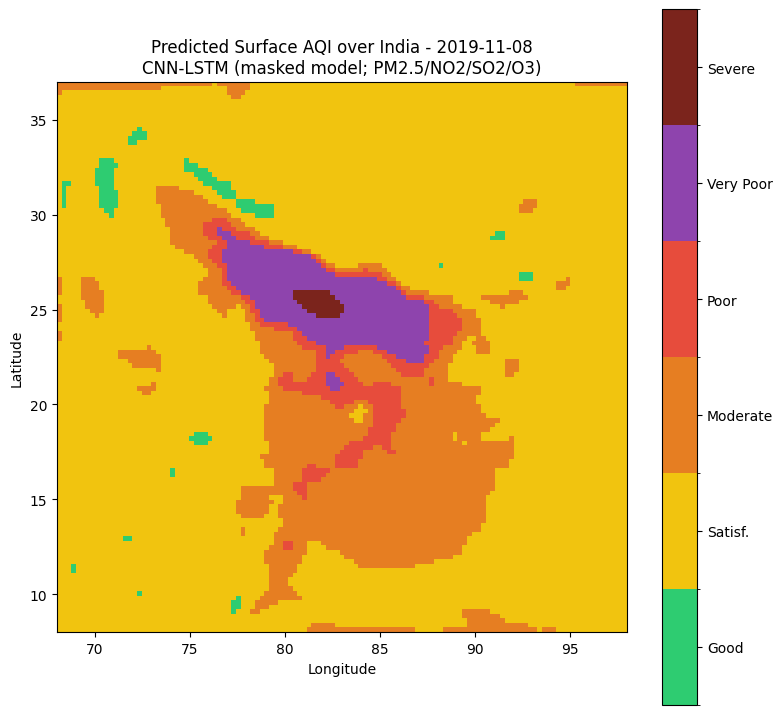

In [21]:
"""
ISRO BAH 2026 - PS3: national AQI map using the improved MASKED model,
with the unreliable CO dropped from the AQI composite.

Output: output/aqi_map_masked_<DATE>.png
"""
import numpy as np, rasterio, os, datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from numpy.lib.stride_tricks import sliding_window_view

GRID_DIR = "data/gee_grid"; DATE = "2019-11-08"; T, K = 5, 5
EXTENT = [68.0, 98.0, 8.0, 37.0]
os.makedirs("output", exist_ok=True)

# AQI from predicted pollutants (CO intentionally excluded)
IP = [0,50,100,200,300,400,500]
CP = {"pm25":[0,30,60,90,120,250,500], "no2":[0,40,80,180,280,400,1000],
      "so2":[0,40,80,380,800,1600,2620], "o3":[0,50,100,168,208,748,1000]}
AQI_TARGETS = ["pm25","no2","so2","o3"]      # no CO

model = tf.keras.models.load_model("models/cnn_lstm_masked.keras",
                                   safe_mode=False, compile=False)
s = np.load("models/scalers_masked.npz", allow_pickle=True)
xmean,xstd,ymean,ystd = s["xmean"],s["xstd"],s["ymean"],s["ystd"]
TARGETS = list(s["target_names"])

def day_array(date):
    with rasterio.open(os.path.join(GRID_DIR, f"{date}.tif")) as ds:
        a = ds.read().astype("float32")
        if ds.nodata is not None: a[a==ds.nodata]=np.nan
    a[np.abs(a)>1e30]=np.nan
    return a

d0 = dt.date.fromisoformat(DATE)
days = [(d0-dt.timedelta(days=k)).isoformat() for k in range(T-1,-1,-1)]
stack = [day_array(dd) for dd in days]
C,H,W = stack[0].shape; pad = K//2
seq = np.empty((H*W,T,K,K,C),dtype="float32")
for ti,a in enumerate(stack):
    a = np.transpose(a,(1,2,0))
    a = np.pad(a,((pad,pad),(pad,pad),(0,0)),mode="edge")
    win = sliding_window_view(a,(K,K),axis=(0,1))
    seq[:,ti] = np.transpose(win,(0,1,3,4,2)).reshape(H*W,K,K,C)
seq = np.nan_to_num((seq-xmean)/xstd, nan=0.0)

pred = np.clip(model.predict(seq,batch_size=2048,verbose=1)*ystd+ymean, 0, None)
# build AQI from the 4 reliable pollutants
subs = []
for t in AQI_TARGETS:
    j = TARGETS.index(t)
    subs.append(np.interp(pred[:,j], CP[t], IP))
aqi = np.max(np.stack(subs,-1),-1).reshape(H,W)
np.save(f"output/aqi_grid_masked_{DATE}.npy", aqi)

bounds=[0,50,100,200,300,400,500]
colors=["#2ECC71","#F1C40F","#E67E22","#E74C3C","#8E44AD","#7B241C"]
cmap=ListedColormap(colors); norm=BoundaryNorm(bounds,cmap.N)
plt.figure(figsize=(8,9))
im=plt.imshow(aqi,extent=EXTENT,origin="upper",cmap=cmap,norm=norm)
cb=plt.colorbar(im,ticks=[25,75,150,250,350,450],shrink=0.8)
cb.ax.set_yticklabels(["Good","Satisf.","Moderate","Poor","Very Poor","Severe"])
plt.title(f"Predicted Surface AQI over India - {DATE}\n"
          "CNN-LSTM (masked model; PM2.5/NO2/SO2/O3)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.savefig(f"output/aqi_map_masked_{DATE}.png",dpi=150)
print("Saved output/aqi_map_masked_%s.png"%DATE)
print("AQI range",int(np.nanmin(aqi)),"-",int(np.nanmax(aqi)),"mean",int(np.nanmean(aqi)))

In [22]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/train_masked.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")

updating: data/gee_grid/ (stored 0%)
updating: data/gee_grid/2024-10-17.tif (deflated 1%)
updating: data/gee_grid/2019-10-22.tif (deflated 1%)
updating: data/gee_grid/2024-11-04.tif (deflated 1%)
updating: data/gee_grid/2024-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-07.tif (deflated 1%)
updating: data/gee_grid/2024-11-13.tif (deflated 1%)
updating: data/gee_grid/2024-11-12.tif (deflated 1%)
updating: data/gee_grid/2024-10-31.tif (deflated 1%)
updating: data/gee_grid/2019-10-28.tif (deflated 1%)
updating: data/gee_grid/2019-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-01.tif (deflated 1%)
updating: data/gee_grid/2019-11-05.tif (deflated 1%)
updating: data/gee_grid/2024-10-27.tif (deflated 1%)
updating: data/gee_grid/2019-11-11.tif (deflated 1%)
updating: data/gee_grid/2024-10-19.tif (deflated 1%)
updating: data/gee_grid/2024-10-24.tif (deflated 1%)
updating: data/gee_grid/2024-10-30.tif (deflated 1%)
updating: data/gee_grid/2019-10-29.tif (deflated 1%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

computed 50 frames
Saved output/aqi_timelapse.gif


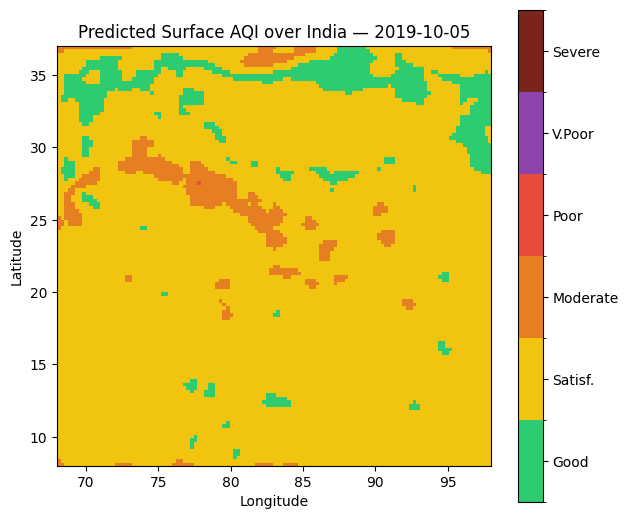

In [23]:
"""
ISRO BAH 2026 - PS3, FEATURE 1: seasonal AQI time-lapse animation.

Runs the masked model over the whole India grid for many dates across the
2019-20 burning season and assembles them into an animated GIF, so you can
WATCH pollution build and move with the stubble-burning season.

Output: output/aqi_timelapse.gif
        output/aqi_frames/<date>.png   (individual frames, reused by dashboard)
"""
import numpy as np, rasterio, os, glob, datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.animation as animation
from numpy.lib.stride_tricks import sliding_window_view

GRID_DIR = "data/gee_grid"; T, K = 5, 5
EXTENT = [68.0, 98.0, 8.0, 37.0]
STRIDE = 3                       # render every 3rd day (faster). set 1 for every day
START, END = dt.date(2019,10,1), dt.date(2020,3,1)
os.makedirs("output/aqi_frames", exist_ok=True)

IP=[0,50,100,200,300,400,500]
CP={"pm25":[0,30,60,90,120,250,500],"no2":[0,40,80,180,280,400,1000],
    "so2":[0,40,80,380,800,1600,2620],"o3":[0,50,100,168,208,748,1000]}
AQI_TARGETS=["pm25","no2","so2","o3"]

model = tf.keras.models.load_model("models/cnn_lstm_masked.keras", compile=False)
s = np.load("models/scalers_masked.npz", allow_pickle=True)
xmean,xstd,ymean,ystd = s["xmean"],s["xstd"],s["ymean"],s["ystd"]
TARGETS=list(s["target_names"])

# cache every season day's raster
def read(date):
    p=os.path.join(GRID_DIR,f"{date}.tif")
    if not os.path.exists(p): return None
    with rasterio.open(p) as ds:
        a=ds.read().astype("float32")
        if ds.nodata is not None: a[a==ds.nodata]=np.nan
    a[np.abs(a)>1e30]=np.nan
    return a

cache={}
d=START
while d<END:
    cache[d.isoformat()]=read(d.isoformat()); d+=dt.timedelta(days=1)

def aqi_for(date):
    days=[(dt.date.fromisoformat(date)-dt.timedelta(days=k)).isoformat() for k in range(T-1,-1,-1)]
    if any(cache.get(dd) is None for dd in days): return None
    C,H,W=cache[days[0]].shape; pad=K//2
    seq=np.empty((H*W,T,K,K,C),dtype="float32")
    for ti,dd in enumerate(days):
        a=np.transpose(cache[dd],(1,2,0))
        a=np.pad(a,((pad,pad),(pad,pad),(0,0)),mode="edge")
        win=sliding_window_view(a,(K,K),axis=(0,1))
        seq[:,ti]=np.transpose(win,(0,1,3,4,2)).reshape(H*W,K,K,C)
    seq=np.nan_to_num((seq-xmean)/xstd,nan=0.0)
    pred=np.clip(model.predict(seq,batch_size=4096,verbose=0)*ystd+ymean,0,None)
    subs=[np.interp(pred[:,TARGETS.index(t)],CP[t],IP) for t in AQI_TARGETS]
    return np.max(np.stack(subs,-1),-1).reshape(H,W)

# build frames
dates=[]
d=START+dt.timedelta(days=T-1)
while d<END:
    dates.append(d.isoformat()); d+=dt.timedelta(days=STRIDE)

bounds=[0,50,100,200,300,400,500]
colors=["#2ECC71","#F1C40F","#E67E22","#E74C3C","#8E44AD","#7B241C"]
cmap=ListedColormap(colors); norm=BoundaryNorm(bounds,cmap.N)

grids=[]; labels=[]
for dte in dates:
    g=aqi_for(dte)
    if g is None: continue
    grids.append(g); labels.append(dte)
    plt.imsave(f"output/aqi_frames/{dte}.png", g, cmap=cmap, vmin=0, vmax=500)
print(f"computed {len(grids)} frames")

fig,ax=plt.subplots(figsize=(7,8))
im=ax.imshow(grids[0],extent=EXTENT,origin="upper",cmap=cmap,norm=norm)
cb=fig.colorbar(im,ticks=[25,75,150,250,350,450],shrink=0.8)
cb.ax.set_yticklabels(["Good","Satisf.","Moderate","Poor","V.Poor","Severe"])
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ttl=ax.set_title("")
def upd(i):
    im.set_data(grids[i]); ttl.set_text(f"Predicted Surface AQI over India — {labels[i]}")
    return im,ttl
ani=animation.FuncAnimation(fig,upd,frames=len(grids),interval=300)
ani.save("output/aqi_timelapse.gif",writer=animation.PillowWriter(fps=4))
print("Saved output/aqi_timelapse.gif")

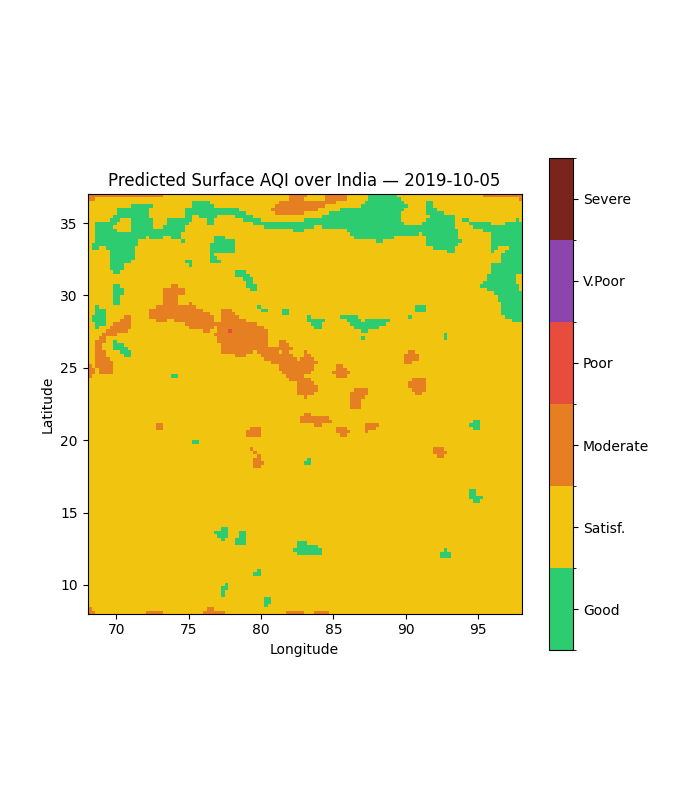

In [24]:
from IPython.display import Image
Image(open("output/aqi_timelapse.gif","rb").read())

In [40]:
"""
ISRO BAH 2026 - PS3, FEATURES 2 & 3: interactive dashboard + health advisory.
Now LAND-MASKED: AQI and hotspots only shown over land (ocean values from
satellite retrievals are noise and were cluttering the sea).

Setup (run once in Colab):  !pip install global-land-mask -q

Output: output/aqi_dashboard.html
"""
import numpy as np, rasterio, os, folium, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from global_land_mask import globe

DATE="2019-11-08"; GRID_DIR="data/gee_grid"
EXTENT=[68.0,98.0,8.0,37.0]; B={"HCHO":4,"FIRE":6}
ALPHA=0.45   # AQI layer opacity: lower=more see-through (try 0.25-0.6)
os.makedirs("output",exist_ok=True)

npy=f"output/aqi_grid_masked_{DATE}.npy"
assert os.path.exists(npy), f"Run 05b_make_aqi_map_masked.py first to create {npy}"
aqi=np.load(npy); H,W=aqi.shape

# ---- land mask for the grid ------------------------------------------------
lats=EXTENT[3]-(np.arange(H)+0.5)*(EXTENT[3]-EXTENT[2])/H
lons=EXTENT[0]+(np.arange(W)+0.5)*(EXTENT[1]-EXTENT[0])/W
lon2d,lat2d=np.meshgrid(lons,lats)
land=globe.is_land(lat2d,lon2d)

def advisory(a):
    if a<=50:  return "Good","Minimal impact. Air is clean.","#2ECC71"
    if a<=100: return "Satisfactory","Minor breathing discomfort to sensitive people.","#F1C40F"
    if a<=200: return "Moderate","Breathing discomfort to people with lung/heart disease, children and older adults.","#E67E22"
    if a<=300: return "Poor","Breathing discomfort to most people on prolonged exposure.","#E74C3C"
    if a<=400: return "Very Poor","Respiratory illness on prolonged exposure. Avoid outdoor activity.","#8E44AD"
    return "Severe","Affects healthy people; serious risk for those with existing conditions. Stay indoors.","#7B241C"

# ---- AQI overlay (transparent over ocean) ----------------------------------
bounds=[0,50,100,200,300,400,500]
colors=["#2ECC71","#F1C40F","#E67E22","#E74C3C","#8E44AD","#7B241C"]
cmap=ListedColormap(colors); norm=BoundaryNorm(bounds,cmap.N)
rgba=cmap(norm(aqi))
rgba[...,3]=np.where(land,1.0,0.0)          # land opaque, ocean transparent

m=folium.Map(location=[23,80],zoom_start=5,tiles="cartodbpositron")
# pass the array directly -> folium embeds it as base64 INSIDE the html
folium.raster_layers.ImageOverlay(name="Predicted Surface AQI",
    image=rgba,
    bounds=[[EXTENT[2],EXTENT[0]],[EXTENT[3],EXTENT[1]]],
    opacity=ALPHA,interactive=False).add_to(m)   # <-- translucency knob

with rasterio.open(os.path.join(GRID_DIR,f"{DATE}.tif")) as ds:
    a=ds.read().astype("float32")
    if ds.nodata is not None: a[a==ds.nodata]=np.nan
a[np.abs(a)>1e30]=np.nan
fire=a[B["FIRE"]]; hcho=a[B["HCHO"]]

def cell_lonlat(r,c):
    return (EXTENT[3]-(r+0.5)*(EXTENT[3]-EXTENT[2])/H,
            EXTENT[0]+(c+0.5)*(EXTENT[1]-EXTENT[0])/W)

fg_fire=folium.FeatureGroup(name="Active fires",show=False)
for r,c in zip(*np.where(np.nan_to_num(fire)>0)):
    if not land[r,c]: continue
    lat,lon=cell_lonlat(r,c)
    folium.CircleMarker([lat,lon],radius=2,color="black",fill=True,fill_opacity=0.7).add_to(fg_fire)
fg_fire.add_to(m)

thr=np.nanmean(hcho)+2*np.nanstd(hcho)
fg_h=folium.FeatureGroup(name="HCHO hotspots",show=False)
for r,c in zip(*np.where(hcho>thr)):
    if not land[r,c]: continue                  # land only
    lat,lon=cell_lonlat(r,c)
    folium.CircleMarker([lat,lon],radius=3,color="purple",fill=True,fill_opacity=0.5).add_to(fg_h)
fg_h.add_to(m)

cities=pd.read_csv("data/ground_labels.csv")[["station","lat","lon"]].drop_duplicates()
def grid_aqi(lat,lon):
    r=min(max(int((EXTENT[3]-lat)/(EXTENT[3]-EXTENT[2])*H),0),H-1)
    c=min(max(int((lon-EXTENT[0])/(EXTENT[1]-EXTENT[0])*W),0),W-1)
    return float(aqi[r,c])
fg_city=folium.FeatureGroup(name="City AQI + advisory",show=True)
for _,row in cities.iterrows():
    a_=grid_aqi(row["lat"],row["lon"]); cat,adv,col=advisory(a_)
    html=f"<b>{row['station']}</b><br>AQI ~ {int(a_)} ({cat})<br><i>{adv}</i>"
    folium.CircleMarker([row["lat"],row["lon"]],radius=7,color=col,fill=True,
        fill_color=col,fill_opacity=0.9,popup=folium.Popup(html,max_width=250)).add_to(fg_city)
fg_city.add_to(m)

legend=("<div style='position:fixed;bottom:30px;left:30px;z-index:9999;background:white;"
        "padding:10px;border:1px solid grey;font-size:12px'><b>Predicted AQI</b><br>"
        "<span style='color:#2ECC71'>&#9632;</span> Good 0-50<br>"
        "<span style='color:#F1C40F'>&#9632;</span> Satisfactory 51-100<br>"
        "<span style='color:#E67E22'>&#9632;</span> Moderate 101-200<br>"
        "<span style='color:#E74C3C'>&#9632;</span> Poor 201-300<br>"
        "<span style='color:#8E44AD'>&#9632;</span> Very Poor 301-400<br>"
        "<span style='color:#7B241C'>&#9632;</span> Severe 401-500<br>"
        f"<br><b>Date:</b> {DATE}</div>")
m.get_root().html.add_child(folium.Element(legend))
folium.LayerControl().add_to(m)
m.save("output/aqi_dashboard.html")
print("Saved output/aqi_dashboard.html (land-masked)")

Saved output/aqi_dashboard.html (land-masked)


In [41]:
from google.colab import files
files.download("output/aqi_dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
!pip install global-land-mask -q

In [31]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/train_masked.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")

updating: data/gee_grid/ (stored 0%)
updating: data/gee_grid/2024-10-17.tif (deflated 1%)
updating: data/gee_grid/2019-10-22.tif (deflated 1%)
updating: data/gee_grid/2024-11-04.tif (deflated 1%)
updating: data/gee_grid/2024-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-07.tif (deflated 1%)
updating: data/gee_grid/2024-11-13.tif (deflated 1%)
updating: data/gee_grid/2024-11-12.tif (deflated 1%)
updating: data/gee_grid/2024-10-31.tif (deflated 1%)
updating: data/gee_grid/2019-10-28.tif (deflated 1%)
updating: data/gee_grid/2019-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-01.tif (deflated 1%)
updating: data/gee_grid/2019-11-05.tif (deflated 1%)
updating: data/gee_grid/2024-10-27.tif (deflated 1%)
updating: data/gee_grid/2019-11-11.tif (deflated 1%)
updating: data/gee_grid/2024-10-19.tif (deflated 1%)
updating: data/gee_grid/2024-10-24.tif (deflated 1%)
updating: data/gee_grid/2024-10-30.tif (deflated 1%)
updating: data/gee_grid/2019-10-29.tif (deflated 1%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/train_masked.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")

updating: data/gee_grid/ (stored 0%)
updating: data/gee_grid/2024-10-17.tif (deflated 1%)
updating: data/gee_grid/2019-10-22.tif (deflated 1%)
updating: data/gee_grid/2024-11-04.tif (deflated 1%)
updating: data/gee_grid/2024-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-07.tif (deflated 1%)
updating: data/gee_grid/2024-11-13.tif (deflated 1%)
updating: data/gee_grid/2024-11-12.tif (deflated 1%)
updating: data/gee_grid/2024-10-31.tif (deflated 1%)
updating: data/gee_grid/2019-10-28.tif (deflated 1%)
updating: data/gee_grid/2019-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-01.tif (deflated 1%)
updating: data/gee_grid/2019-11-05.tif (deflated 1%)
updating: data/gee_grid/2024-10-27.tif (deflated 1%)
updating: data/gee_grid/2019-11-11.tif (deflated 1%)
updating: data/gee_grid/2024-10-19.tif (deflated 1%)
updating: data/gee_grid/2024-10-24.tif (deflated 1%)
updating: data/gee_grid/2024-10-30.tif (deflated 1%)
updating: data/gee_grid/2019-10-29.tif (deflated 1%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
"""
ISRO BAH 2026 - PS3: build a DATE-SELECTABLE static web app.

Runs the masked model for every date in the season, saves a land-masked AQI
overlay per date, samples city AQI per date, and generates a single-folder
website (Leaflet + a date slider). No server needed.

Output folder: output/web/
    index.html            <- open this / deploy this folder
    overlays/<date>.png   <- per-date AQI layers
The whole 'web' folder can be opened locally OR hosted on GitHub Pages / Netlify.
"""
import numpy as np, rasterio, os, json, datetime as dt, io, base64
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from global_land_mask import globe

GRID_DIR="data/gee_grid"; T,K=5,5
EXTENT=[68.0,98.0,8.0,37.0]
STRIDE=2                       # every 2nd day (set 1 for every day, slower)
START,END=dt.date(2019,10,1),dt.date(2020,3,1)
WEB="output/web"; os.makedirs(WEB+"/overlays",exist_ok=True)

IP=[0,50,100,200,300,400,500]
CP={"pm25":[0,30,60,90,120,250,500],"no2":[0,40,80,180,280,400,1000],
    "so2":[0,40,80,380,800,1600,2620],"o3":[0,50,100,168,208,748,1000]}
AQI_TARGETS=["pm25","no2","so2","o3"]

model=tf.keras.models.load_model("models/cnn_lstm_masked.keras",compile=False)
s=np.load("models/scalers_masked.npz",allow_pickle=True)
xmean,xstd,ymean,ystd=s["xmean"],s["xstd"],s["ymean"],s["ystd"]; TARGETS=list(s["target_names"])

def read(date):
    p=os.path.join(GRID_DIR,f"{date}.tif")
    if not os.path.exists(p): return None
    with rasterio.open(p) as ds:
        a=ds.read().astype("float32")
        if ds.nodata is not None: a[a==ds.nodata]=np.nan
    a[np.abs(a)>1e30]=np.nan; return a

cache={}; d=START
while d<END: cache[d.isoformat()]=read(d.isoformat()); d+=dt.timedelta(days=1)

# grid geometry + land mask
H=W=None
for v in cache.values():
    if v is not None: _,H,W=v.shape; break
lats=EXTENT[3]-(np.arange(H)+0.5)*(EXTENT[3]-EXTENT[2])/H
lons=EXTENT[0]+(np.arange(W)+0.5)*(EXTENT[1]-EXTENT[0])/W
lon2d,lat2d=np.meshgrid(lons,lats); land=globe.is_land(lat2d,lon2d)

bounds=[0,50,100,200,300,400,500]
colors=["#2ECC71","#F1C40F","#E67E22","#E74C3C","#8E44AD","#7B241C"]
cmap=ListedColormap(colors); norm=BoundaryNorm(bounds,cmap.N)

def aqi_for(date):
    days=[(dt.date.fromisoformat(date)-dt.timedelta(days=k)).isoformat() for k in range(T-1,-1,-1)]
    if any(cache.get(dd) is None for dd in days): return None
    pad=K//2; seq=np.empty((H*W,T,K,K,12),dtype="float32")
    for ti,dd in enumerate(days):
        a=np.transpose(cache[dd],(1,2,0)); a=np.pad(a,((pad,pad),(pad,pad),(0,0)),mode="edge")
        win=sliding_window_view(a,(K,K),axis=(0,1))
        seq[:,ti]=np.transpose(win,(0,1,3,4,2)).reshape(H*W,K,K,12)
    seq=np.nan_to_num((seq-xmean)/xstd,nan=0.0)
    pred=np.clip(model.predict(seq,batch_size=4096,verbose=0)*ystd+ymean,0,None)
    subs=[np.interp(pred[:,TARGETS.index(t)],CP[t],IP) for t in AQI_TARGETS]
    return np.max(np.stack(subs,-1),-1).reshape(H,W)

cities=pd.read_csv("data/ground_labels.csv")[["station","lat","lon"]].drop_duplicates()
def grid_val(g,lat,lon):
    r=min(max(int((EXTENT[3]-lat)/(EXTENT[3]-EXTENT[2])*H),0),H-1)
    c=min(max(int((lon-EXTENT[0])/(EXTENT[1]-EXTENT[0])*W),0),W-1)
    return float(g[r,c])

dates=[]; d=START+dt.timedelta(days=T-1)
while d<END: dates.append(d.isoformat()); d+=dt.timedelta(days=STRIDE)

out_dates=[]; city_aqi={}; fires={}; hcho_pts={}; overlays_uri={}
for dte in dates:
    g=aqi_for(dte)
    if g is None: continue
    rgba=cmap(norm(g)); rgba[...,3]=np.where(land,1.0,0.0)
    buf=io.BytesIO(); plt.imsave(buf,rgba,format="png")
    overlays_uri[dte]="data:image/png;base64,"+base64.b64encode(buf.getvalue()).decode()
    city_aqi[dte]={r["station"]:round(grid_val(g,r["lat"],r["lon"])) for _,r in cities.iterrows()}
    a=cache[dte]; fire=a[6]; hch=a[4]
    fr,fc=np.where((np.nan_to_num(fire)>0)&land)
    fires[dte]=[[round(float(lats[r]),3),round(float(lons[c]),3)] for r,c in zip(fr,fc)]
    thr=np.nanmean(hch)+2*np.nanstd(hch)
    hr,hc=np.where((hch>thr)&land)
    hcho_pts[dte]=[[round(float(lats[r]),3),round(float(lons[c]),3)] for r,c in zip(hr,hc)]
    out_dates.append(dte)
print("built",len(out_dates),"dates")

DATA={"dates":out_dates,"bounds":[[EXTENT[2],EXTENT[0]],[EXTENT[3],EXTENT[1]]],
      "overlays":overlays_uri,
      "cities":[{"name":r["station"],"lat":r["lat"],"lon":r["lon"]} for _,r in cities.iterrows()],
      "city_aqi":city_aqi,"fires":fires,"hcho":hcho_pts}

LEGEND=("<b>Predicted AQI</b><br>"
 "<span class=sw style='background:#2ECC71'></span>Good<br>"
 "<span class=sw style='background:#F1C40F'></span>Satisfactory<br>"
 "<span class=sw style='background:#E67E22'></span>Moderate<br>"
 "<span class=sw style='background:#E74C3C'></span>Poor<br>"
 "<span class=sw style='background:#8E44AD'></span>Very Poor<br>"
 "<span class=sw style='background:#7B241C'></span>Severe")

HTML=r"""<!DOCTYPE html><html><head><meta charset="utf-8">
<title>India Surface AQI — ISRO BAH 2026</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<style>
 body{margin:0;font-family:Arial,sans-serif}#map{height:100vh}
 #panel{position:absolute;top:10px;left:60px;z-index:1000;background:#fff;padding:12px 16px;border-radius:8px;box-shadow:0 1px 6px rgba(0,0,0,.3);max-width:340px}
 #legend{position:absolute;bottom:24px;left:12px;z-index:1000;background:#fff;padding:10px;border-radius:8px;font-size:12px;box-shadow:0 1px 6px rgba(0,0,0,.3)}
 .sw{display:inline-block;width:12px;height:12px;margin-right:5px;border:1px solid #999}
 input[type=range]{width:300px}#datelbl{font-weight:bold;color:#b00}
</style></head><body>
<div id="map"></div>
<div id="panel">
 <b>Predicted Surface AQI over India</b><br>
 <small>CNN-LSTM from satellite + meteorology · ISRO BAH 2026</small><br><br>
 Date: <span id="datelbl"></span><br>
 <input type="range" id="slider" min="0" value="0"/><br>
 <small>Drag the slider to change the date. Click any city dot for its AQI and health advisory.</small>
</div>
<div id="legend">__LEGEND__</div>
<script>
const DATA=__DATA__;
const map=L.map('map').setView([23,80],5);
L.tileLayer('https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
 {attribution:'&copy; OpenStreetMap &copy; CARTO'}).addTo(map);
function adv(a){
 if(a<=50)return["Good","Minimal impact. Air is clean.","#2ECC71"];
 if(a<=100)return["Satisfactory","Minor breathing discomfort to sensitive people.","#F1C40F"];
 if(a<=200)return["Moderate","Discomfort to people with lung/heart disease, children and older adults.","#E67E22"];
 if(a<=300)return["Poor","Breathing discomfort to most people on prolonged exposure.","#E74C3C"];
 if(a<=400)return["Very Poor","Respiratory illness on prolonged exposure. Avoid outdoor activity.","#8E44AD"];
 return["Severe","Serious health risk. Stay indoors.","#7B241C"];}

// layers
let aqiLayer=L.imageOverlay(DATA.overlays[DATA.dates[0]],DATA.bounds,{opacity:0.5}).addTo(map);
let fireLayer=L.layerGroup();
let hchoLayer=L.layerGroup();
let cityLayer=L.layerGroup().addTo(map);
const markers={};
DATA.cities.forEach(c=>{markers[c.name]=L.circleMarker([c.lat,c.lon],
 {radius:7,color:'#333',weight:1,fillOpacity:0.9}).addTo(cityLayer);});
L.control.layers(null,{
 "Predicted Surface AQI":aqiLayer,
 "Active fires":fireLayer,
 "HCHO hotspots":hchoLayer,
 "City AQI + advisory":cityLayer},{collapsed:false}).addTo(map);

const slider=document.getElementById('slider');slider.max=DATA.dates.length-1;
function render(i){const d=DATA.dates[i];document.getElementById('datelbl').textContent=d;
 aqiLayer.setUrl(DATA.overlays[d]);
 DATA.cities.forEach(c=>{const a=DATA.city_aqi[d][c.name];const v=adv(a);
  markers[c.name].setStyle({fillColor:v[2]});
  markers[c.name].bindPopup('<b>'+c.name+'</b><br>AQI ~ '+Math.round(a)+' ('+v[0]+')<br><i>'+v[1]+'</i>');});
 fireLayer.clearLayers();
 (DATA.fires[d]||[]).forEach(p=>L.circleMarker(p,{radius:2,color:'black',fillOpacity:0.7}).addTo(fireLayer));
 hchoLayer.clearLayers();
 (DATA.hcho[d]||[]).forEach(p=>L.circleMarker(p,{radius:3,color:'purple',weight:1,fillOpacity:0.5}).addTo(hchoLayer));}
slider.addEventListener('input',e=>render(+e.target.value));render(0);
</script></body></html>"""

html=HTML.replace("__DATA__",json.dumps(DATA)).replace("__LEGEND__",LEGEND)
open(f"{WEB}/index.html","w").write(html)
print("Saved",WEB+"/index.html  — open it, or deploy the whole 'web' folder")

built 74 dates
Saved output/web/index.html  — open it, or deploy the whole 'web' folder


In [46]:
!zip -r web_app.zip output/web
from google.colab import files
files.download("web_app.zip")

updating: output/web/ (stored 0%)
updating: output/web/index.html (deflated 83%)
updating: output/web/overlays/ (stored 0%)
updating: output/web/overlays/2020-02-16.png (stored 0%)
updating: output/web/overlays/2020-02-22.png (stored 0%)
updating: output/web/overlays/2019-11-14.png (stored 0%)
updating: output/web/overlays/2020-01-29.png (stored 0%)
updating: output/web/overlays/2020-01-15.png (stored 0%)
updating: output/web/overlays/2020-01-07.png (stored 0%)
updating: output/web/overlays/2019-12-08.png (stored 0%)
updating: output/web/overlays/2020-01-13.png (stored 0%)
updating: output/web/overlays/2020-01-05.png (stored 0%)
updating: output/web/overlays/2019-12-16.png (stored 0%)
updating: output/web/overlays/2020-01-31.png (stored 0%)
updating: output/web/overlays/2019-10-05.png (stored 0%)
updating: output/web/overlays/2020-01-03.png (stored 0%)
updating: output/web/overlays/2019-11-28.png (stored 0%)
updating: output/web/overlays/2019-12-28.png (stored 0%)
updating: output/web/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from google.colab import files
files.download("output/web/index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
from google.colab import files
!zip -r isro_ps3_work.zip data/gee_grid data/train.npz data/train_masked.npz data/ground_labels.csv models output
files.download("isro_ps3_work.zip")

updating: data/gee_grid/ (stored 0%)
updating: data/gee_grid/2024-10-17.tif (deflated 1%)
updating: data/gee_grid/2019-10-22.tif (deflated 1%)
updating: data/gee_grid/2024-11-04.tif (deflated 1%)
updating: data/gee_grid/2024-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-07.tif (deflated 1%)
updating: data/gee_grid/2024-11-13.tif (deflated 1%)
updating: data/gee_grid/2024-11-12.tif (deflated 1%)
updating: data/gee_grid/2024-10-31.tif (deflated 1%)
updating: data/gee_grid/2019-10-28.tif (deflated 1%)
updating: data/gee_grid/2019-10-16.tif (deflated 1%)
updating: data/gee_grid/2019-11-01.tif (deflated 1%)
updating: data/gee_grid/2019-11-05.tif (deflated 1%)
updating: data/gee_grid/2024-10-27.tif (deflated 1%)
updating: data/gee_grid/2019-11-11.tif (deflated 1%)
updating: data/gee_grid/2024-10-19.tif (deflated 1%)
updating: data/gee_grid/2024-10-24.tif (deflated 1%)
updating: data/gee_grid/2024-10-30.tif (deflated 1%)
updating: data/gee_grid/2019-10-29.tif (deflated 1%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>